# **Import Libraries**

In [435]:
from google.colab import drive
drive.mount('/content/drive')
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from scipy.stats import shapiro, f_oneway, stats
from statsmodels.stats.multicomp import MultiComparison
from yellowbrick.regressor import ResidualsPlot

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Regression algorithms for farm areas**



In [436]:
# Load data
all_areas_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/files/output/final/data_integration_all_areas_final.csv")

In [437]:
all_areas_df.select_dtypes(include=['int64','float64'])

,index,farm,area_cod,area_size,CO2_emission_area,CO2_emission_ha,CO2_stock_area,CO2_stock_ha,balance_CO2_area,balance_CO2_ha,city_cod,state_cod,biome_cod,climate_cod,year
0,1,4576327,3,5.35,0.000000,0.000000,167.718896,31.349326,167.718896,31.349326,1100908,11,1,2,2021
1,2,4576327,12,0.27,1.996577,7.394729,8.463050,31.344631,6.466474,23.949902,1100908,11,1,2,2021
2,3,4576327,15,69.79,516.078138,7.394729,2044.337396,29.292698,1528.259257,21.897969,1100908,11,1,2,2021
3,4,4574927,3,3.23,0.000000,0.000000,101.258324,31.349326,101.258324,31.349326,1100908,11,1,2,2021
4,5,4574927,12,0.30,2.218419,7.394729,9.403389,31.344631,7.184971,23.949902,1100908,11,1,2,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22795,22796,13894,12,0.08,0.394706,4.933824,2.159577,26.994707,1.764871,22.060882,2312908,23,2,3,2021
22796,22797,4749410,3,2.08,0.000000,0.000000,76.117710,36.595053,76.117710,36.595053,2312908,23,2,3,2021
22797,22798,4749410,4,82.95,0.000000,0.000000,2347.975103,28.305908,2347.975103,28.305908,2312908,23,2,3,2021
22798,22799,4749410,12,0.68,3.355000,4.933824,18.356401,26.994707,15.001400,22.060882,2312908,23,2,3,2021


<Axes: >

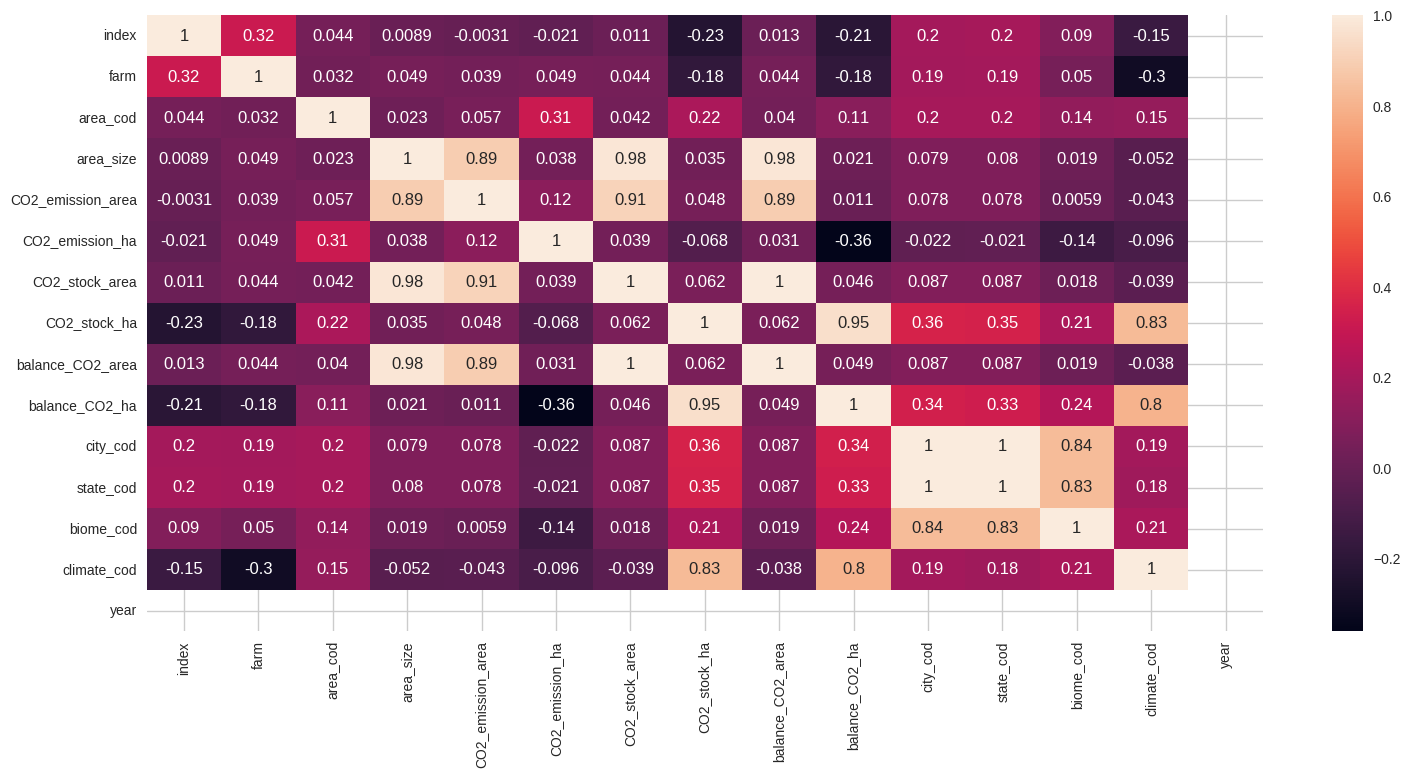

In [438]:
# Correlation
all_areas_df_corr = all_areas_df.select_dtypes(include=['int64','float64'])
figura = plt.figure(figsize=(18,8))
sns.heatmap(all_areas_df_corr.corr(), annot=True)

In [439]:
all_areas_df.count()

,0
index,22800
farm,22800
area_cod,22800
area_name,22800
area_size,22800
CO2_emission_area,22800
CO2_emission_ha,22800
CO2_stock_area,22800
CO2_stock_ha,22800
balance_CO2_area,22800


#**Linear Regression - Simple**

In [440]:
# X is the attribute: area_cod (predictor attribute) => (area_cod: 2, climate_cod: 17)
X_areas = all_areas_df.iloc[:, 17].values
X_areas

array([2, 2, 2, ..., 3, 3, 3])

In [441]:
# Y is the attribute: balance_CO2_ha
Y_areas = all_areas_df.iloc[:, 10].values
Y_areas

array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

In [442]:
X_areas.shape, Y_areas.shape

((22800,), (22800,))

In [443]:
# Correlation coefficient
np.corrcoef(X_areas, Y_areas)

array([[1.        , 0.80127047],
       [0.80127047, 1.        ]])

In [444]:
# Transforming array into matrix (required for sklearn)
X_areas = X_areas.reshape(-1,1)
X_areas

array([[2],
       [2],
       [2],
       ...,
       [3],
       [3],
       [3]])

In [445]:
X_areas.shape

(22800, 1)

**Standardization, if necessary**

In [446]:
scaler_areas_x = StandardScaler()
X_areas = scaler_areas_x.fit_transform((X_areas).reshape(-1,1))
scaler_areas_y = StandardScaler()
Y_areas = scaler_areas_y.fit_transform((Y_areas).reshape(-1,1))
X_areas, Y_areas

(array([[-1.27582858],
        [-1.27582858],
        [-1.27582858],
        ...,
        [-0.80008457],
        [-0.80008457],
        [-0.80008457]]),
 array([[-0.46585766],
        [-1.24586181],
        [-1.46216467],
        ...,
        [-0.78667704],
        [-1.44499128],
        [-1.72514839]]))

**Using the entire database**

In [447]:
# Create the regression model (for all data)
simple_linear_regressor = LinearRegression()
simple_linear_regressor.fit(X_areas, Y_areas)

LinearRegression()

In [448]:
# b0 : beginning of the regression line and b1: slope of the line
simple_linear_regressor.intercept_, simple_linear_regressor.coef_

(array([2.9502217e-16]), array([[0.80127047]]))

In [449]:
# Prevision
prevision_simple_linear_regressor = simple_linear_regressor.predict(X_areas)
prevision_simple_linear_regressor

array([[-1.02228376],
       [-1.02228376],
       [-1.02228376],
       ...,
       [-0.64108414],
       [-0.64108414],
       [-0.64108414]])

In [450]:
# Convert matrix to array (for the graph)
X_areas.ravel()

array([-1.27582858, -1.27582858, -1.27582858, ..., -0.80008457,
       -0.80008457, -0.80008457])

In [451]:
# Prediction with a value  (area 15) = estimated value of carbon/ha
simple_linear_regressor.intercept_ + simple_linear_regressor.coef_ * 15

array([[12.01905702]])

In [452]:
# OR using matrix format
simple_linear_regressor.predict([[15]])

array([[12.01905702]])

In [453]:
# score: algorithm quality metric (closest to 1 best value)
simple_linear_regressor.score(X_areas, Y_areas)

0.6420343627481244

In [454]:
# Mean absolute error
mean_absolute_error(Y_areas, prevision_simple_linear_regressor)

0.4671374914568191

In [455]:
# Mean squared error
mean_squared_error(Y_areas, prevision_simple_linear_regressor)

0.3579656372518755

In [456]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas, prevision_simple_linear_regressor))

np.float64(0.5983022958771557)

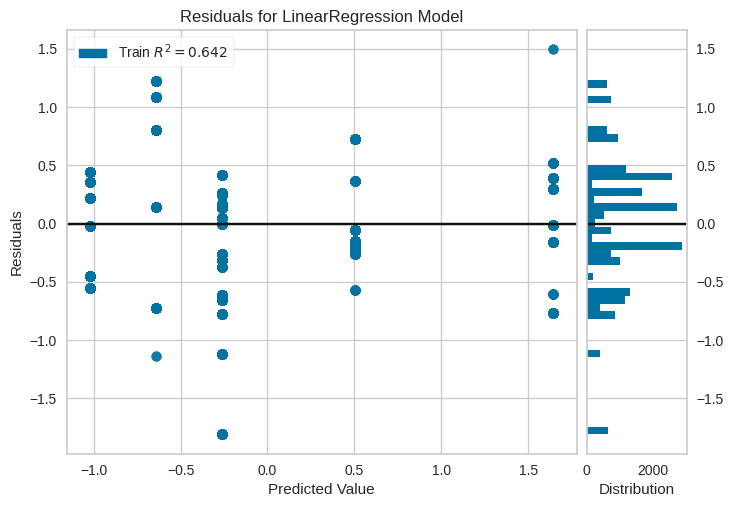

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [457]:
# distance from the original values to the linear regression line (Train R2 = algorithm quality)
viewer = ResidualsPlot(simple_linear_regressor)
viewer.fit(X_areas, Y_areas)
viewer.poof()

<Axes: >

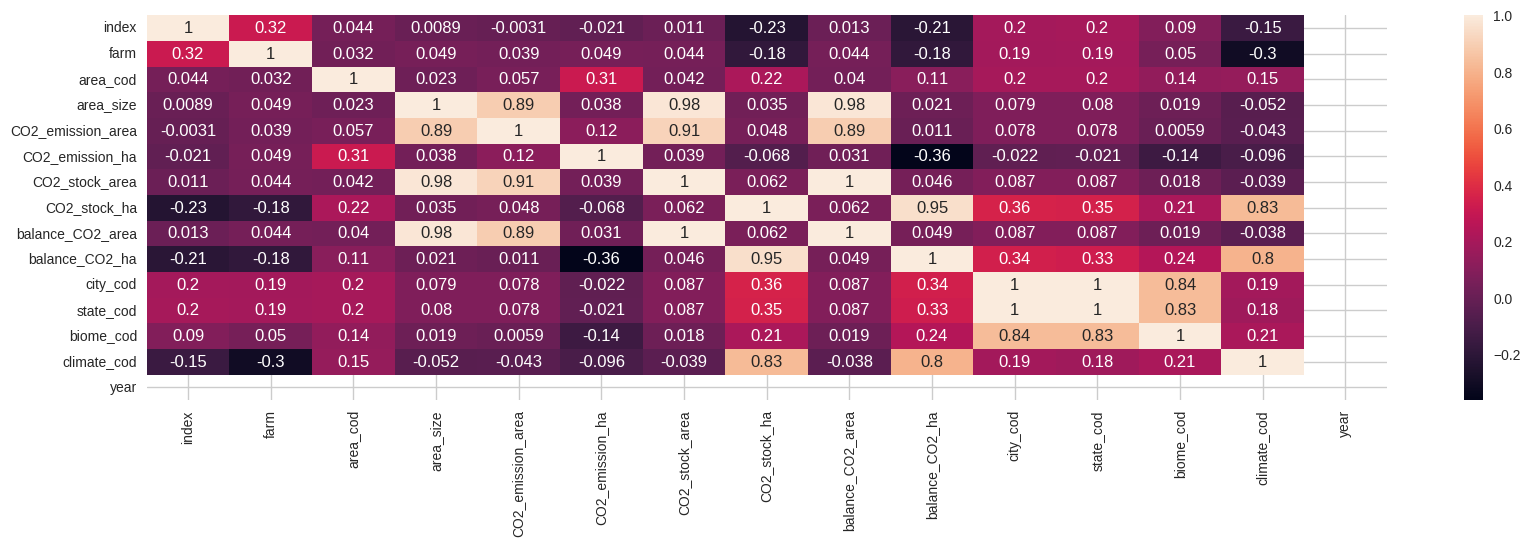

In [458]:
# Correlation viewer
figure = plt.figure(figsize=(20,5))
sns.heatmap(all_areas_df_corr.corr(), annot=True)

**Simple Linear Regression - training and testing bases**

In [459]:
# Division of bases (75% trein, 25% test)
X_areas_trein, X_areas_test, Y_areas_trein, Y_areas_test = train_test_split(X_areas, Y_areas, test_size = 0.25, random_state = 0)

In [460]:
X_areas_trein.shape, Y_areas_trein.shape, X_areas_test.shape, Y_areas_test.shape

((17100, 1), (17100, 1), (5700, 1), (5700, 1))


**Standardization, if necessary**

In [461]:
scaler_areas_x = StandardScaler()
X_areas_trein = scaler_areas_x.fit_transform((X_areas_trein).reshape(-1,1))
X_areas_test = scaler_areas_x.fit_transform((X_areas_test).reshape(-1,1))

scaler_areas_y = StandardScaler()
Y_areas_trein = scaler_areas_y.fit_transform((Y_areas_trein).reshape(-1,1))
Y_areas_test = scaler_areas_y.fit_transform((Y_areas_test).reshape(-1,1))

X_areas_trein, Y_areas_trein, X_areas_test, Y_areas_test


(array([[ 2.04293687],
        [ 2.04293687],
        [-0.33024732],
        ...,
        [-0.33024732],
        [-0.33024732],
        [ 2.04293687]]),
 array([[ 1.33939139],
        [ 1.33939139],
        [-0.43073256],
        ...,
        [-0.68259947],
        [-0.68259947],
        [ 1.33939139]]),
 array([[ 0.65193813],
        [ 2.08966603],
        [-0.30654713],
        ...,
        [ 2.08966603],
        [-0.30654713],
        [-0.78578976]]),
 array([[ 0.78860646],
        [ 1.3769533 ],
        [ 0.01619678],
        ...,
        [ 1.28449882],
        [-0.40969116],
        [-1.43640598]]))

**Regression Model for training**

In [462]:
# Convert array to matrix
X_areas_trein = X_areas_trein.reshape(-1,1)
X_areas_trein

array([[ 2.04293687],
       [ 2.04293687],
       [-0.33024732],
       ...,
       [-0.33024732],
       [-0.33024732],
       [ 2.04293687]])

In [463]:
# Create the regression model (trein)
simple_linear_regressor_trein = LinearRegression()
simple_linear_regressor_trein.fit(X_areas_trein, Y_areas_trein)

LinearRegression()

In [464]:
# score: algorithm quality metric (trein)
simple_linear_regressor_trein.score(X_areas_trein, Y_areas_trein)

0.6402051597659755

In [465]:
# Prevision (trein)
prevision_simple_linear_regressor_trein = simple_linear_regressor_trein.predict(X_areas_trein)
prevision_simple_linear_regressor_trein

array([[ 1.63461143],
       [ 1.63461143],
       [-0.26424019],
       ...,
       [-0.26424019],
       [-0.26424019],
       [ 1.63461143]])

In [466]:
# Real data
Y_areas_trein

array([[ 1.33939139],
       [ 1.33939139],
       [-0.43073256],
       ...,
       [-0.68259947],
       [-0.68259947],
       [ 1.33939139]])

In [467]:
# Mean absolute error
abs(Y_areas_trein-prevision_simple_linear_regressor_trein).mean()

np.float64(0.4676665495531181)

In [468]:
# Mean absolute error
mean_absolute_error(Y_areas_trein, prevision_simple_linear_regressor_trein)

0.4676665495531181

In [469]:
# Mean squared error
mean_squared_error(Y_areas_trein, prevision_simple_linear_regressor_trein)

0.3597948402340246

In [470]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_trein, prevision_simple_linear_regressor_trein))

np.float64(0.5998290091634654)

In [471]:
# Prediction with a value  (area 15) = estimated value of carbon/ha
simple_linear_regressor_trein.intercept_ + simple_linear_regressor_trein.coef_ * 15

array([[12.00192322]])

**Regression Model for testing**

In [472]:
# Convert array to matrix
X_areas_test = X_areas_test.reshape(-1,1)
X_areas_test

array([[ 0.65193813],
       [ 2.08966603],
       [-0.30654713],
       ...,
       [ 2.08966603],
       [-0.30654713],
       [-0.78578976]])

In [473]:
# Create the regression model (test)
simple_linear_regressor_test = LinearRegression()
simple_linear_regressor_test.fit(X_areas_test, Y_areas_test)

LinearRegression()

In [474]:
# score: algorithm quality metric (test)
simple_linear_regressor_test.score(X_areas_test, Y_areas_test)

0.6474830714261044

In [475]:
# Prevision (test)
prevision_simple_linear_regressor_test = simple_linear_regressor_test.predict(X_areas_test)
prevision_simple_linear_regressor_test

array([[ 0.52459071],
       [ 1.68147762],
       [-0.24666723],
       ...,
       [ 1.68147762],
       [-0.24666723],
       [-0.6322962 ]])

In [476]:
# Real data
Y_areas_test

array([[ 0.78860646],
       [ 1.3769533 ],
       [ 0.01619678],
       ...,
       [ 1.28449882],
       [-0.40969116],
       [-1.43640598]])

In [477]:
# Mean absolute error
abs(Y_areas_test-prevision_simple_linear_regressor_test).mean()

np.float64(0.4656144869597011)

In [478]:
# Mean absolute error
mean_absolute_error(Y_areas_test, prevision_simple_linear_regressor_test)

0.4656144869597011

In [479]:
# Mean squared error
mean_squared_error(Y_areas_test, prevision_simple_linear_regressor_test)

0.35251692857389566

In [480]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_test, prevision_simple_linear_regressor_test))

np.float64(0.5937313606117632)

In [481]:
# Prediction with a value  (area 15) = estimated value of carbon/ha
simple_linear_regressor_trein.intercept_ + simple_linear_regressor_trein.coef_ * 15

array([[12.00192322]])

# **Linear Regression - Multiple**

In [482]:
# X composed of attributes: area_cod, city_cod, climate_cod
X_areas_mult = all_areas_df.iloc[:, [2,11,17]].values
X_areas_mult

array([[      3, 1100908,       2],
       [     12, 1100908,       2],
       [     15, 1100908,       2],
       ...,
       [      4, 2312908,       3],
       [     12, 2312908,       3],
       [     15, 2312908,       3]])

In [483]:
# # Y is the attribute: balance_CO2_ha
Y_areas_mult = all_areas_df.iloc[:, 10].values
Y_areas_mult

array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

**Using the entire database**

**Standardization, if necessary**

In [484]:
scaler_areas_x = StandardScaler()
X_areas_mult = scaler_areas_x.fit_transform((X_areas_mult))
scaler_areas_y = StandardScaler()
Y_areas_mult = scaler_areas_y.fit_transform((Y_areas_mult).reshape(-1,1))
X_areas_mult, Y_areas_mult

(array([[-1.04928986, -1.91303817, -1.27582858],
        [-0.31583817, -1.91303817, -1.27582858],
        [-0.07135427, -1.91303817, -1.27582858],
        ...,
        [-0.96779522, -1.05597807, -0.80008457],
        [-0.31583817, -1.05597807, -0.80008457],
        [-0.07135427, -1.05597807, -0.80008457]]),
 array([[-0.46585766],
        [-1.24586181],
        [-1.46216467],
        ...,
        [-0.78667704],
        [-1.44499128],
        [-1.72514839]]))

In [485]:
# Create the regression model (for all data)
mult_linear_regressor = LinearRegression()
mult_linear_regressor.fit(X_areas_mult, Y_areas_mult)

LinearRegression()

In [486]:
# Prevision
prevision_mult_linear_regressor = mult_linear_regressor.predict(X_areas_mult)
prevision_mult_linear_regressor

array([[-1.32661987],
       [-1.36023794],
       [-1.37144396],
       ...,
       [-0.78820661],
       [-0.81808933],
       [-0.82929536]])

In [487]:
# score: algorithm quality metric (closest to 1 best value)
mult_linear_regressor.score(X_areas_mult, Y_areas_mult)

0.6815844043984757

In [488]:
# Mean absolute error
mean_absolute_error(Y_areas_mult, prevision_mult_linear_regressor)

0.42333404478816516

In [489]:
# Mean squared error
mean_squared_error(Y_areas_mult, prevision_mult_linear_regressor)

0.3184155956015243

In [490]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult, prevision_mult_linear_regressor))

np.float64(0.5642832583034201)

**Multiple Linear Regression - training and testing bases**

In [491]:
# Division of bases (75% trein, 25% test)
X_areas_mult_trein, X_areas_mult_test, Y_areas_mult_trein, Y_areas_mult_test = train_test_split(X_areas_mult, Y_areas_mult, test_size = 0.25, random_state = 0)

In [492]:
X_areas_mult_trein.shape, Y_areas_mult_trein.shape, X_areas_mult_test.shape, Y_areas_mult_test.shape

((17100, 3), (17100, 1), (5700, 3), (5700, 1))

**Standardization, if necessary**


In [493]:
scaler_areas_x_mult = StandardScaler()
X_areas_mult_trein = scaler_areas_x_mult.fit_transform((X_areas_mult_trein))
X_areas_mult_test = scaler_areas_x_mult.fit_transform((X_areas_mult_test))

scaler_areas_y_mult = StandardScaler()
Y_areas_mult_trein = scaler_areas_y_mult.fit_transform((Y_areas_mult_trein))
Y_areas_mult_test = scaler_areas_y_mult.fit_transform((Y_areas_mult_test))

X_areas_mult_trein, Y_areas_mult_trein, X_areas_mult_test, Y_areas_mult_test

(array([[ 0.41451135, -0.47463678,  2.04293687],
        [ 0.41451135, -0.47463678,  2.04293687],
        [ 0.41451135,  0.92012512, -0.33024732],
        ...,
        [-0.07364724,  0.92012512, -0.33024732],
        [-0.07364724,  0.92012512, -0.33024732],
        [ 0.41451135, -0.47463678,  2.04293687]]),
 array([[ 1.33939139],
        [ 1.33939139],
        [-0.43073256],
        ...,
        [-0.68259947],
        [-0.68259947],
        [ 1.33939139]]),
 array([[ 2.06512812,  0.36946258,  0.65193813],
        [ 0.42700428, -0.45481924,  2.08966603],
        [-0.96540098,  0.92096828, -0.30654713],
        ...,
        [-0.06443287, -0.45481924,  2.08966603],
        [ 0.42700428,  0.9208521 , -0.30654713],
        [-0.31015145, -1.03518365, -0.78578976]]),
 array([[ 0.78860646],
        [ 1.3769533 ],
        [ 0.01619678],
        ...,
        [ 1.28449882],
        [-0.40969116],
        [-1.43640598]]))

**Regression Model for training**

In [494]:
# Create the regression model (trein)
mult_linear_regressor_trein = LinearRegression()
mult_linear_regressor_trein.fit(X_areas_mult_trein, Y_areas_mult_trein)

LinearRegression()

In [495]:
# score: algorithm quality metric (trein)
mult_linear_regressor_trein.score(X_areas_mult_trein, Y_areas_mult_trein)

0.6792615566341829

In [496]:
# Prevision (trein)
prevision_mult_linear_regressor_trein = mult_linear_regressor_trein.predict(X_areas_mult_trein)
prevision_mult_linear_regressor_trein

array([[ 1.45726819],
       [ 1.45726819],
       [-0.08404048],
       ...,
       [-0.0631642 ],
       [-0.0631642 ],
       [ 1.45726819]])

In [497]:
# Real data
Y_areas_mult_trein

array([[ 1.33939139],
       [ 1.33939139],
       [-0.43073256],
       ...,
       [-0.68259947],
       [-0.68259947],
       [ 1.33939139]])

In [498]:
# Mean absolute error
mean_absolute_error(Y_areas_mult_trein, prevision_mult_linear_regressor_trein)

0.42539509861300384

In [499]:
# Mean squared error
mean_squared_error(Y_areas_mult_trein, prevision_mult_linear_regressor_trein)

0.3207384433658172

In [500]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult_trein, prevision_mult_linear_regressor_trein))

np.float64(0.5663377467252356)

**Regression Model for testing**

In [501]:
# Create the regression model (test)
mult_linear_regressor_test = LinearRegression()
mult_linear_regressor_test.fit(X_areas_mult_test, Y_areas_mult_test)

LinearRegression()

In [502]:
# score: algorithm quality metric (test)
mult_linear_regressor_test.score(X_areas_mult_test, Y_areas_mult_test)

0.6886482482037015

In [503]:
# Prevision (test)
prevision_mult_linear_regressor_test = mult_linear_regressor_test.predict(X_areas_mult_test)
prevision_mult_linear_regressor_test

array([[ 0.46495725],
       [ 1.4883318 ],
       [ 0.0107573 ],
       ...,
       [ 1.5154669 ],
       [-0.06614987],
       [-0.80450261]])

In [504]:
# Real data
Y_areas_mult_test

array([[ 0.78860646],
       [ 1.3769533 ],
       [ 0.01619678],
       ...,
       [ 1.28449882],
       [-0.40969116],
       [-1.43640598]])

In [505]:
# Mean absolute error
mean_absolute_error(Y_areas_mult_test, prevision_mult_linear_regressor_test)

0.417546294169748

In [506]:
# Mean squared error
mean_squared_error(Y_areas_mult_test, prevision_mult_linear_regressor_test)

0.3113517517962984

In [507]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult_test, prevision_mult_linear_regressor_test))

np.float64(0.5579890247991428)

# **Polynomial Regression**

In [508]:
# X is the attribute: area_cod (predictor attribute) => (area_cod: 2, climate_cod: 17)
X_areas = all_areas_df.iloc[:, 17].values
X_areas

array([2, 2, 2, ..., 3, 3, 3])

In [509]:
# Y is the attribute: balance_CO2_ha
Y_areas = all_areas_df.iloc[:, 10].values
Y_areas

array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

In [510]:
scaler_polynomial_x = StandardScaler()
X_areas  = scaler_polynomial_x.fit_transform(X_areas.reshape(-1,1))
X_areas

array([[-1.27582858],
       [-1.27582858],
       [-1.27582858],
       ...,
       [-0.80008457],
       [-0.80008457],
       [-0.80008457]])

In [511]:
scaler_polynomial_y = StandardScaler()
Y_areas  = scaler_polynomial_y.fit_transform(Y_areas.reshape(-1,1))
Y_areas

array([[-0.46585766],
       [-1.24586181],
       [-1.46216467],
       ...,
       [-0.78667704],
       [-1.44499128],
       [-1.72514839]])

In [512]:
# Apply degree to the polynomial
polynomial_degree = PolynomialFeatures(degree=8)

**Using the entire database**

In [513]:
# Transforming array into matrix (required for sklearn)
X_areas = X_areas.reshape(-1,1)
X_areas

array([[-1.27582858],
       [-1.27582858],
       [-1.27582858],
       ...,
       [-0.80008457],
       [-0.80008457],
       [-0.80008457]])

In [514]:
# Apply polynominal degree in X
X_areas_poly = polynomial_degree.fit_transform(X_areas)

In [515]:
X_areas_poly.shape

(22800, 9)

In [516]:
X_areas_poly

array([[ 1.        , -1.27582858,  1.62773856, ...,  4.31274677,
        -5.50232558,  7.02002423],
       [ 1.        , -1.27582858,  1.62773856, ...,  4.31274677,
        -5.50232558,  7.02002423],
       [ 1.        , -1.27582858,  1.62773856, ...,  4.31274677,
        -5.50232558,  7.02002423],
       ...,
       [ 1.        , -0.80008457,  0.64013532, ...,  0.26231032,
        -0.20987044,  0.1679141 ],
       [ 1.        , -0.80008457,  0.64013532, ...,  0.26231032,
        -0.20987044,  0.1679141 ],
       [ 1.        , -0.80008457,  0.64013532, ...,  0.26231032,
        -0.20987044,  0.1679141 ]])

In [517]:
# Create the regression model (for all data)
poly_simple_linear_regressor = LinearRegression()
poly_simple_linear_regressor.fit(X_areas_poly, Y_areas)

LinearRegression()

In [518]:
# Score: algorithm quality metric (closest to 1 best value)
poly_simple_linear_regressor.score(X_areas_poly, Y_areas)

0.7165754415363537

In [519]:
# Prevision
prevision_poly_simple_linear_regressor = poly_simple_linear_regressor.predict(X_areas_poly)
prevision_poly_simple_linear_regressor

array([[-1.032336  ],
       [-1.032336  ],
       [-1.032336  ],
       ...,
       [-1.19611949],
       [-1.19611949],
       [-1.19611949]])

In [520]:
# Real data
Y_areas

array([[-0.46585766],
       [-1.24586181],
       [-1.46216467],
       ...,
       [-0.78667704],
       [-1.44499128],
       [-1.72514839]])

In [521]:
# Mean absolute error
mean_absolute_error(Y_areas, prevision_poly_simple_linear_regressor)

0.4399946687126049

In [522]:
# Mean squared error
mean_squared_error(Y_areas, prevision_poly_simple_linear_regressor)

0.2834245584636463

In [523]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas, prevision_poly_simple_linear_regressor))

np.float64(0.5323763316148139)

In [524]:
# Prevision
new_value = [[15]]
new_value = polynomial_degree.transform(new_value)
new_value

array([[1.00000000e+00, 1.50000000e+01, 2.25000000e+02, 3.37500000e+03,
        5.06250000e+04, 7.59375000e+05, 1.13906250e+07, 1.70859375e+08,
        2.56289062e+09]])

In [525]:
poly_simple_linear_regressor.predict(new_value)

array([[5.26551486e+08]])

**Polynomial Linear Regression - training and testing bases**

In [526]:
# Division of bases (75% trein, 25% test)
X_areas_trein, X_areas_test, Y_areas_trein, Y_areas_test = train_test_split(X_areas, Y_areas, test_size = 0.25, random_state = 0)

**Regression Model for training**

In [527]:
X_areas_trein.shape, Y_areas_trein.shape

((17100, 1), (17100, 1))

In [528]:
# Transforming array into matrix (required for sklearn)
X_areas_trein = X_areas_trein.reshape(-1,1)
X_areas_trein

array([[ 2.05437947],
       [ 2.05437947],
       [-0.32434056],
       ...,
       [-0.32434056],
       [-0.32434056],
       [ 2.05437947]])

In [529]:
# Apply polynominal degree in X
X_areas_trein_poly = polynomial_degree.fit_transform(X_areas_trein)
X_areas_trein_poly.shape

(17100, 9)

In [530]:
# Create the regression model
poly_simple_linear_regressor_trein = LinearRegression()
poly_simple_linear_regressor_trein.fit(X_areas_trein_poly, Y_areas_trein)

LinearRegression()

In [531]:
# Score: algorithm quality metric (closest to 1 best value)
poly_simple_linear_regressor_trein.score(X_areas_trein_poly, Y_areas_trein)

0.7151488649131478

In [532]:
# Prevision
prevision_poly_simple_linear_regressor_trein = poly_simple_linear_regressor_trein.predict(X_areas_trein_poly)
prevision_poly_simple_linear_regressor_trein

array([[ 1.55322842],
       [ 1.55322842],
       [-0.0037246 ],
       ...,
       [-0.0037246 ],
       [-0.0037246 ],
       [ 1.55322842]])

In [533]:
# Real data
Y_areas_trein

array([[ 1.34862742],
       [ 1.34862742],
       [-0.42548064],
       ...,
       [-0.67791444],
       [-0.67791444],
       [ 1.34862742]])

In [534]:
# Mean absolute error
mean_absolute_error(Y_areas_trein, prevision_poly_simple_linear_regressor_trein)

0.4420434273563239

In [535]:
# Mean squared error
mean_squared_error(Y_areas_trein, prevision_poly_simple_linear_regressor_trein)

0.28613484008819184

In [536]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_trein, prevision_poly_simple_linear_regressor_trein))

np.float64(0.5349157317636039)

**Regression Model for testing**

In [537]:
X_areas_test.shape, Y_areas_test.shape

((5700, 1), (5700, 1))

In [538]:
# Transforming array into matrix (required for sklearn)
X_areas_test = X_areas_test.reshape(-1,1)
X_areas_test

array([[ 0.62714745],
       [ 2.05437947],
       [-0.32434056],
       ...,
       [ 2.05437947],
       [-0.32434056],
       [-0.80008457]])

In [539]:
# Apply polynominal degree in X
X_areas_test_poly = polynomial_degree.fit_transform(X_areas_test)
X_areas_test_poly.shape

(5700, 9)

In [540]:
# Create the regression model
poly_simple_linear_regressor_test = LinearRegression()
poly_simple_linear_regressor_test.fit(X_areas_test_poly, Y_areas_test)

LinearRegression()

In [541]:
# Score: algorithm quality metric (closest to 1 best value)
poly_simple_linear_regressor_test.score(X_areas_test_poly, Y_areas_test)

0.7209327435180226

In [542]:
# Prevision
prevision_poly_simple_linear_regressor_test = poly_simple_linear_regressor_test.predict(X_areas_test_poly)
prevision_poly_simple_linear_regressor_test

array([[ 0.4659656 ],
       [ 1.54330301],
       [-0.01153764],
       ...,
       [ 1.54330301],
       [-0.01153764],
       [-1.18935491]])

In [543]:
# Real data
Y_areas_test

array([[ 0.76440886],
       [ 1.34862742],
       [-0.00258105],
       ...,
       [ 1.25682168],
       [-0.42548064],
       [-1.44499128]])

In [544]:
# Mean absolute error
mean_absolute_error(Y_areas_test, prevision_poly_simple_linear_regressor_test)

0.43366517124053866

In [545]:
# Mean squared error
mean_squared_error(Y_areas_test, prevision_poly_simple_linear_regressor_test)

0.2751647201075029

In [546]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_test, prevision_poly_simple_linear_regressor_test))

np.float64(0.5245614550341103)

# **Polynomial Regression - Multiple**

In [547]:
# X composed of attributes: area_cod, city_cod, climate_cod
X_areas_mult = all_areas_df.iloc[:, [2,11,17]].values
X_areas_mult

array([[      3, 1100908,       2],
       [     12, 1100908,       2],
       [     15, 1100908,       2],
       ...,
       [      4, 2312908,       3],
       [     12, 2312908,       3],
       [     15, 2312908,       3]])

In [548]:
# Y is the attribute: balance_CO2_ha
Y_areas_mult = all_areas_df.iloc[:, [10]].values
Y_areas_mult

array([[31.34932631],
       [23.9499024 ],
       [21.89796901],
       ...,
       [28.30590842],
       [22.06088245],
       [19.40320279]])

**Standardization, in this algorithm is very important**

In [549]:
scaler_mult_polynomial_x = StandardScaler()
X_areas_mult  = scaler_mult_polynomial_x.fit_transform(X_areas_mult)
X_areas_mult

array([[-1.04928986, -1.91303817, -1.27582858],
       [-0.31583817, -1.91303817, -1.27582858],
       [-0.07135427, -1.91303817, -1.27582858],
       ...,
       [-0.96779522, -1.05597807, -0.80008457],
       [-0.31583817, -1.05597807, -0.80008457],
       [-0.07135427, -1.05597807, -0.80008457]])

In [550]:
scaler_mult_polynomial_y = StandardScaler()
Y_areas_mult  = scaler_mult_polynomial_y.fit_transform(Y_areas_mult)
Y_areas_mult

array([[-0.46585766],
       [-1.24586181],
       [-1.46216467],
       ...,
       [-0.78667704],
       [-1.44499128],
       [-1.72514839]])

In [551]:
X_areas_mult.shape, Y_areas_mult.shape

((22800, 3), (22800, 1))

In [552]:
# Apply degree to the polynomial
mult_polynomial_degree = PolynomialFeatures(degree=5)

**Using the entire database**

In [553]:
# Apply polynominal degree in X
X_areas_mult_poly = mult_polynomial_degree.fit_transform(X_areas_mult)

In [554]:
X_areas_mult_poly.shape

(22800, 56)

In [555]:
# Create the regression model (for all data)
mult_poly_simple_linear_regressor = LinearRegression()
mult_poly_simple_linear_regressor.fit(X_areas_mult_poly, Y_areas_mult)

LinearRegression()

In [556]:
# Score: algorithm quality metric (closest to 1 best value)
mult_poly_simple_linear_regressor.score(X_areas_mult_poly, Y_areas_mult)

0.9773558532238572

In [557]:
# Prevision
prevision_mult_poly_simple_linear_regressor = mult_poly_simple_linear_regressor.predict(X_areas_mult_poly)
prevision_mult_poly_simple_linear_regressor

array([[-0.44050166],
       [-1.2388991 ],
       [-1.45964422],
       ...,
       [-0.63358043],
       [-1.58628133],
       [-1.65082705]])

In [558]:
# Real data
Y_areas_mult

array([[-0.46585766],
       [-1.24586181],
       [-1.46216467],
       ...,
       [-0.78667704],
       [-1.44499128],
       [-1.72514839]])

In [559]:
# Mean absolute error
mean_absolute_error(Y_areas_mult, prevision_mult_poly_simple_linear_regressor)

0.08539771474114864

In [560]:
# Mean squared error
mean_squared_error(Y_areas_mult, prevision_mult_poly_simple_linear_regressor)

0.02264414677614279

In [561]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult, prevision_mult_poly_simple_linear_regressor))

np.float64(0.1504797221426953)

**Cross Validation**

In [562]:
# Apply degree to the polynomial
mult_polynomial_degree = PolynomialFeatures(degree=15)

In [563]:
# Apply polynominal degree in X
X_areas_mult_poly = mult_polynomial_degree.fit_transform(X_areas_mult)

In [564]:
# Cross Validation Polynomial Regression (Multiple)
results_polynomial = []
for i in range(60):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  mult_polynomial_degree = PolynomialFeatures(degree=4)
  X_areas_mult_poly = mult_polynomial_degree.fit_transform(X_areas_mult)
  poly = LinearRegression()
  scores = cross_val_score(poly, X_areas_mult_poly, Y_areas_mult, cv=kfold)
  results_polynomial.append(scores.mean())

results_polynomial

[np.float64(0.9542198635742762),
 np.float64(0.9541079968462794),
 np.float64(0.9542327689850124),
 np.float64(0.9540834863794905),
 np.float64(0.9543116747011917),
 np.float64(0.9542925911237118),
 np.float64(0.9542382686229633),
 np.float64(0.9542956947348505),
 np.float64(0.9543091874113093),
 np.float64(0.9542721000843872),
 np.float64(0.9542318720169956),
 np.float64(0.9541998214219822),
 np.float64(0.9542173163744581),
 np.float64(0.9542687190914672),
 np.float64(0.9541440676671824),
 np.float64(0.9541839036215405),
 np.float64(0.9542514848513133),
 np.float64(0.9542508099651854),
 np.float64(0.9542150525186444),
 np.float64(0.9543085064377674),
 np.float64(0.9542390099647806),
 np.float64(0.9541734804943063),
 np.float64(0.9542388192542127),
 np.float64(0.9541636725533772),
 np.float64(0.9541331553353933),
 np.float64(0.9541436820631221),
 np.float64(0.9541932690362633),
 np.float64(0.954225883485177),
 np.float64(0.95421327822467),
 np.float64(0.9543221623808831),
 np.float64(0

**Multiple Linear Regression - training and testing bases**

In [565]:
# Division of bases (75% trein, 25% test)
X_areas_mult_trein, X_areas_mult_test, Y_areas_mult_trein, Y_areas_mult_test = train_test_split(X_areas_mult, Y_areas_mult, test_size = 0.25, random_state = 0)

In [566]:
X_areas_mult_trein.shape, Y_areas_mult_trein.shape, X_areas_mult_test.shape, Y_areas_mult_test.shape

((17100, 3), (17100, 1), (5700, 3), (5700, 1))

In [567]:
# Apply degree to the polynomial
mult_polynomial_degree = PolynomialFeatures(degree=15)

**Regression Model for training**

In [568]:
# Apply polynominal degree in X
X_areas_multi_poly_trein = mult_polynomial_degree.fit_transform(X_areas_mult_trein)

In [569]:
# Cross Validation Polynomial Regression (Multiple)
results_polynomial = []
for i in range(60):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  mult_polynomial_degree = PolynomialFeatures(degree=4)
  X_areas_multi_poly_trein = mult_polynomial_degree.fit_transform(X_areas_mult_trein)
  poly = LinearRegression()
  scores = cross_val_score(poly, X_areas_multi_poly_trein, Y_areas_mult_trein, cv=kfold)
  results_polynomial.append(scores.mean())

results_polynomial

[np.float64(0.9551212567633176),
 np.float64(0.9551032698474493),
 np.float64(0.9550932195460108),
 np.float64(0.9550787909803395),
 np.float64(0.955047077723329),
 np.float64(0.9551223839475572),
 np.float64(0.9550821768784129),
 np.float64(0.9551870323626466),
 np.float64(0.9551267161654902),
 np.float64(0.9552395448837775),
 np.float64(0.955227247162588),
 np.float64(0.9552333987559875),
 np.float64(0.9551635084168625),
 np.float64(0.9551126625406109),
 np.float64(0.9552234679198097),
 np.float64(0.9551427326237822),
 np.float64(0.955252582806686),
 np.float64(0.9551068291032326),
 np.float64(0.955023248735378),
 np.float64(0.9552331345390014),
 np.float64(0.955215428046003),
 np.float64(0.9550495494386162),
 np.float64(0.9550930828954753),
 np.float64(0.9552341477795077),
 np.float64(0.9552045556937662),
 np.float64(0.9552043731113429),
 np.float64(0.9551573180205499),
 np.float64(0.9552528956518497),
 np.float64(0.9551368890313612),
 np.float64(0.9551398783611618),
 np.float64(0.9

In [570]:
# Create the regression model (for trein data)
poly_mult_linear_regressor = LinearRegression()
poly_mult_linear_regressor.fit(X_areas_multi_poly_trein, Y_areas_mult_trein)

LinearRegression()

In [571]:
# Score: algorithm quality metric (closest to 1 best value)
poly_mult_linear_regressor.score(X_areas_multi_poly_trein , Y_areas_mult_trein)

0.9555231822154896

In [572]:
# Prevision
prevision_poly_mult_linear_regressor_trein = poly_mult_linear_regressor.predict(X_areas_multi_poly_trein)
prevision_poly_mult_linear_regressor_trein

array([[ 1.22213132],
       [ 1.22213132],
       [-0.36089901],
       ...,
       [-0.70902703],
       [-0.70902703],
       [ 1.22213132]])

In [573]:
# Real data
Y_areas_mult_trein

array([[ 1.34862742],
       [ 1.34862742],
       [-0.42548064],
       ...,
       [-0.67791444],
       [-0.67791444],
       [ 1.34862742]])

In [574]:
# Mean absolute error
mean_absolute_error(Y_areas_mult_trein, prevision_poly_mult_linear_regressor_trein)

0.13780381566951233

In [575]:
# Mean squared error
mean_squared_error(Y_areas_mult_trein, prevision_poly_mult_linear_regressor_trein)

0.04467725621146715

In [576]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult_trein, prevision_poly_mult_linear_regressor_trein))

np.float64(0.21136995106085243)


**Regression Model for testing**

**Cross Validation**

In [577]:
# Apply degree to the polynomial
mult_polynomial_degree = PolynomialFeatures(degree=15)

In [578]:
# Apply polynominal degree in X
X_areas_multi_poly_test = mult_polynomial_degree.fit_transform(X_areas_mult_test)

In [579]:
# Cross Validation Polynomial Regression (Multiple)
results_polynomial = []
for i in range(60):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  mult_polynomial_degree = PolynomialFeatures(degree=4)
  X_areas_multi_poly_test = mult_polynomial_degree.fit_transform(X_areas_mult_test)
  poly = LinearRegression()
  scores = cross_val_score(poly, X_areas_multi_poly_test, Y_areas_mult_test, cv=kfold)
  results_polynomial.append(scores.mean())

results_polynomial

[np.float64(0.9504705340775604),
 np.float64(0.950625187268793),
 np.float64(0.9510087571499225),
 np.float64(0.9507665819499188),
 np.float64(0.9497248193695518),
 np.float64(0.9502942211774863),
 np.float64(0.9505773860134779),
 np.float64(0.9503153522577257),
 np.float64(0.9504866125593809),
 np.float64(0.9497589456689577),
 np.float64(0.950607943883908),
 np.float64(0.9506531044285005),
 np.float64(0.9502847444225073),
 np.float64(0.9505974307955707),
 np.float64(0.9503887982311292),
 np.float64(0.950337157211426),
 np.float64(0.950645075119094),
 np.float64(0.9508062660237163),
 np.float64(0.9506006649528962),
 np.float64(0.9505093715880957),
 np.float64(0.9507290389641432),
 np.float64(0.950806639683568),
 np.float64(0.9507550559735783),
 np.float64(0.9509189036933525),
 np.float64(0.9509358138709689),
 np.float64(0.9508655701237911),
 np.float64(0.9506184416680759),
 np.float64(0.9503344106575312),
 np.float64(0.9500734328025919),
 np.float64(0.9505323468969484),
 np.float64(0.9

In [580]:
# Create the regression model (for test data)
poly_mult_linear_regressor = LinearRegression()
poly_mult_linear_regressor.fit(X_areas_multi_poly_test, Y_areas_mult_test)

LinearRegression()

In [581]:
# Score: algorithm quality metric (closest to 1 best value)
poly_mult_linear_regressor.score(X_areas_multi_poly_test , Y_areas_mult_test)

0.951806798030387

In [582]:
# Prevision
prevision_poly_mult_linear_regressor_test = poly_mult_linear_regressor.predict(X_areas_multi_poly_test)
prevision_poly_mult_linear_regressor_test

array([[-0.48304575],
       [ 1.19007756],
       [ 0.17336554],
       ...,
       [ 1.41701874],
       [-0.36529244],
       [-1.51445501]])

In [583]:
# Real Data
Y_areas_mult_test

array([[ 0.76440886],
       [ 1.34862742],
       [-0.00258105],
       ...,
       [ 1.25682168],
       [-0.42548064],
       [-1.44499128]])

In [584]:
# Mean absolute error
mean_absolute_error(Y_areas_mult_test, prevision_poly_mult_linear_regressor_test)

0.1445281392087859

In [585]:
# Mean squared error
mean_squared_error(Y_areas_mult_test, prevision_poly_mult_linear_regressor_test)

0.04751925789584471

In [586]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult_test, prevision_poly_mult_linear_regressor_test))

np.float64(0.21798912334298864)

# **Decision Tree Regression**

In [587]:
# X is the attribute: area_cod (predictor attribute) => (area_cod: 2, city_cod: 11, climate_cod: 17)
X_areas_tree = all_areas_df.iloc[:, [2]].values
X_areas_tree

array([[ 3],
       [12],
       [15],
       ...,
       [ 4],
       [12],
       [15]])

In [588]:
# Y is the attribute: balance_CO2_ha
Y_areas_tree  = all_areas_df.iloc[:, 10].values
Y_areas_tree

array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

**standardization**

In [589]:
scaler_areas_tree = StandardScaler()
X_areas_tree  = scaler_areas_tree.fit_transform(X_areas_tree)
X_areas_tree

array([[-1.04928986],
       [-0.31583817],
       [-0.07135427],
       ...,
       [-0.96779522],
       [-0.31583817],
       [-0.07135427]])

In [590]:
X_areas_tree.shape

(22800, 1)

**Using the entire database**

In [591]:
regressor_areas_tree = DecisionTreeRegressor()
regressor_areas_tree.fit(X_areas_tree, Y_areas_tree)

DecisionTreeRegressor()

In [592]:
# Prevision
prevision_areas_tree = regressor_areas_tree.predict(X_areas_tree)
prevision_areas_tree[:10]

array([40.62144703, 33.96084637, 29.83188697, 40.62144703, 33.96084637,
       29.83188697, 40.62144703, 29.83188697, 29.83188697, 29.83188697])

In [593]:
Y_areas_tree[:10]

array([31.34932631, 23.9499024 , 21.89796901, 31.34932631, 23.9499024 ,
       21.89796901, 31.34932631, 21.89796901, 21.89796901, 21.89796901])

In [594]:
# Score
regressor_areas_tree.score(X_areas_tree,Y_areas_tree)

0.2573133733910621

In [595]:
max_min_areas_tree = np.arange(np.min(X_areas_tree), np.max(X_areas_tree), 1)
max_min_areas_tree

array([-1.04928986, -0.04928986,  0.95071014,  1.95071014])

In [596]:
max_min_areas_tree.shape

(4,)

In [597]:
# Array to matrix
max_min_areas_tree = max_min_areas_tree.reshape(-1,1)
max_min_areas_tree.shape

(4, 1)

In [598]:
# Predict new value
regressor_areas_tree.predict([[9]])

array([57.14453484])

In [599]:
# Mean absolute error
mean_absolute_error(Y_areas_tree, prevision_areas_tree)

6.4562387037429225

In [600]:
# Mean squared error
mean_squared_error(Y_areas_tree, prevision_areas_tree)

66.83556022312499

In [601]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree, prevision_areas_tree))

np.float64(8.175301842936747)

**Decision Tree Regression - training and testing bases**

In [602]:
# Division of bases (75% trein, 25% test)
X_areas_tree_trein, X_areas_tree_test, Y_areas_tree_trein, Y_areas_tree_test = train_test_split(X_areas_tree, Y_areas_tree, test_size = 0.25, random_state = 0)
X_areas_tree_trein.shape, Y_areas_tree_trein.shape, X_areas_tree_test.shape, Y_areas_tree_test.shape

((17100, 1), (17100,), (5700, 1), (5700,))

**Decision Tree for training**

In [603]:
regressor_areas_tree = DecisionTreeRegressor()
regressor_areas_tree.fit(X_areas_tree_trein, Y_areas_tree_trein)

DecisionTreeRegressor()

In [604]:
# Prevision
prevision_areas_tree_trein = regressor_areas_tree.predict(X_areas_tree_trein)
prevision_areas_tree_trein[:10]

array([35.67371324, 35.67371324, 35.67371324, 34.03334075, 29.90336477,
       35.67371324, 35.67371324, 35.67371324, 40.64426883, 29.90336477])

In [605]:
Y_areas_tree_trein[:10]

array([48.5622402 , 48.5622402 , 31.73235842, 22.06088245, 21.89796901,
       31.73235842, 31.73235842, 31.73235842, 52.89525574, 21.89796901])

In [606]:
# Score
regressor_areas_tree.score(X_areas_tree_trein,Y_areas_tree_trein)

0.258375460165821

In [607]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_trein, prevision_areas_tree_trein)

6.465009972315875

In [608]:
# Mean squared error
mean_squared_error(Y_areas_tree_trein, prevision_areas_tree_trein)

67.040750530816

In [609]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_trein, prevision_areas_tree_trein))

np.float64(8.187841628342357)


**Decision Tree for testing**

In [610]:
regressor_areas_tree = DecisionTreeRegressor()
regressor_areas_tree.fit(X_areas_tree_test, Y_areas_tree_test)

DecisionTreeRegressor()

In [611]:
# Prevision
prevision_areas_tree_test = regressor_areas_tree.predict(X_areas_tree_test)
prevision_areas_tree_test[:10]

array([35.84904152, 35.68476771, 32.88754322, 33.7585858 , 32.88754322,
       40.1387862 , 35.84904152, 32.88754322, 35.68476771, 29.62056387])

In [612]:
Y_areas_tree_test[:10]

array([43.02011476, 48.5622402 , 35.74414912, 22.06088245, 35.74414912,
       50.47760445, 30.98005279, 35.74414912, 42.23133208, 30.81781452])

In [613]:
# Score
regressor_areas_tree.score(X_areas_tree_test,Y_areas_tree_test)

0.25412709173837056

In [614]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_test, prevision_areas_tree_test)

6.427710014717395

In [615]:
# Mean squared error
mean_squared_error(Y_areas_tree_test, prevision_areas_tree_test)

66.18364619300837

In [616]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_test, prevision_areas_tree_test))

np.float64(8.135333194959403)

# Decision Tree Regression - **Multiple**

In [617]:
# X composed of attributes: area_cod, city_cod, climate_cod (area_cod: 2, city_cod: 11, climate_cod: 17)
X_areas_tree_mult = all_areas_df.iloc[:, [2,11,17]].values
X_areas_tree_mult

array([[      3, 1100908,       2],
       [     12, 1100908,       2],
       [     15, 1100908,       2],
       ...,
       [      4, 2312908,       3],
       [     12, 2312908,       3],
       [     15, 2312908,       3]])

In [618]:
# Y is the attribute: balance_CO2_ha
Y_areas_tree_mult  = all_areas_df.iloc[:, [10]].values
Y_areas_tree_mult

array([[31.34932631],
       [23.9499024 ],
       [21.89796901],
       ...,
       [28.30590842],
       [22.06088245],
       [19.40320279]])

**Standardization:**
If you use it, you have to do the conversion in the prevision

In [619]:
scaler_areas_tree_mult = StandardScaler()
X_areas_tree_mult  = scaler_areas_tree_mult.fit_transform(X_areas_tree_mult)
X_areas_tree_mult

array([[-1.04928986, -1.91303817, -1.27582858],
       [-0.31583817, -1.91303817, -1.27582858],
       [-0.07135427, -1.91303817, -1.27582858],
       ...,
       [-0.96779522, -1.05597807, -0.80008457],
       [-0.31583817, -1.05597807, -0.80008457],
       [-0.07135427, -1.05597807, -0.80008457]])

In [620]:
X_areas_tree_mult.shape

(22800, 3)

In [621]:
regressor_areas_tree_mult = DecisionTreeRegressor()
regressor_areas_tree_mult.fit(X_areas_tree_mult, Y_areas_tree_mult)

DecisionTreeRegressor()

In [622]:
prevision_area_tree_mult = regressor_areas_tree_mult.predict(X_areas_tree_mult)
prevision_area_tree_mult[:10]

array([31.34932631, 23.9499024 , 21.89796901, 31.34932631, 23.9499024 ,
       21.89796901, 31.34932631, 21.89796901, 21.89796901, 21.89796901])

In [623]:
Y_areas_tree_mult[:10].ravel()

array([31.34932631, 23.9499024 , 21.89796901, 31.34932631, 23.9499024 ,
       21.89796901, 31.34932631, 21.89796901, 21.89796901, 21.89796901])

In [624]:
# Score
regressor_areas_tree_mult.score(X_areas_tree_mult,Y_areas_tree_mult)

1.0

In [625]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_mult, prevision_area_tree_mult)

3.528525619837334e-13

In [626]:
# Mean squared error
mean_squared_error(Y_areas_tree_mult, prevision_area_tree_mult)

2.030112564189994e-25

In [627]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_mult, prevision_area_tree_mult))

np.float64(4.505677045894428e-13)

In [628]:
# Predicting a value
regressor_areas_tree_mult.predict([[46,3161403,8]])

array([57.14453484])

In [629]:
# Cross Validation Decision Tree Regression (Multiple)
results_tree = []
for i in range(120):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  tree = DecisionTreeRegressor()
  scores = cross_val_score(tree, X_areas_tree_mult, Y_areas_tree_mult, cv=kfold)
  results_tree.append(scores.mean())

results_tree

[np.float64(1.0),
 np.float64(0.9997653713492574),
 np.float64(1.0),
 np.float64(0.9997466001065123),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.9997566416977419),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.9994948963859323),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.9997640426901432),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.9997605554555464),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.9995227978850358),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.9997675365861938),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0)

**Multiple Decision Tree Regression - training and testing bases**

In [630]:
# # Division of bases (75% trein, 25% test)
X_areas_tree_mult_trein, X_areas_tree_mult_test, Y_areas_tree_mult_trein, Y_areas_tree_mult_test = train_test_split(X_areas_tree_mult, Y_areas_tree_mult, test_size = 0.25, random_state = 0)
X_areas_tree_mult_trein.shape, Y_areas_tree_mult_trein.shape, X_areas_tree_mult_test.shape, Y_areas_tree_mult_test.shape

((17100, 3), (17100, 1), (5700, 3), (5700, 1))

**Multiple Decision Tree for training**

In [631]:
regressor_areas_tree_mult_trein = DecisionTreeRegressor()
regressor_areas_tree_mult_trein.fit(X_areas_tree_mult_trein, Y_areas_tree_mult_trein)

DecisionTreeRegressor()

In [632]:
prevision_area_tree_mult_trein = regressor_areas_tree_mult_trein.predict(X_areas_tree_mult_trein)
prevision_area_tree_mult_trein[:10]

array([48.5622402 , 48.5622402 , 31.73235842, 22.06088245, 21.89796901,
       31.73235842, 31.73235842, 31.73235842, 52.89525574, 21.89796901])

In [633]:
Y_areas_tree_mult_trein[:10].ravel()

array([48.5622402 , 48.5622402 , 31.73235842, 22.06088245, 21.89796901,
       31.73235842, 31.73235842, 31.73235842, 52.89525574, 21.89796901])

In [634]:
# Score
regressor_areas_tree_mult_trein.score(X_areas_tree_mult_trein,Y_areas_tree_mult_trein)

1.0

In [635]:
# Predict a new value
regressor_areas_tree_mult_trein.predict([[46,3161403,8]])

array([57.14453484])

In [636]:
53.49693611

53.49693611

In [637]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_mult_trein, prevision_area_tree_mult_trein)

3.636391512793114e-13

In [638]:
# Mean squared error
mean_squared_error(Y_areas_tree_mult_trein, prevision_area_tree_mult_trein)

1.8042682986945128e-25

In [639]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_mult_trein, prevision_area_tree_mult_trein))

np.float64(4.24766794687922e-13)

In [640]:
max_min_areas_tree = np.arange(np.min(X_areas_tree_mult_trein), np.max(X_areas_tree_mult_trein), 1)
max_min_areas_tree

array([-1.91303817, -0.91303817,  0.08696183,  1.08696183,  2.08696183])

In [641]:
# Array to matrix
max_min_areas_tree = max_min_areas_tree.reshape(-1,1)
max_min_areas_tree.shape

(5, 1)

In [642]:
# Cross Validation Decision Tree Regression - Trein(Multiple)
results_tree_trein = []
for i in range(30):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  tree = DecisionTreeRegressor()
  scores = cross_val_score(tree, X_areas_tree_mult_trein, Y_areas_tree_mult_trein, cv=kfold)
  results_tree_trein.append(scores.mean())

results_tree_trein

[np.float64(0.9996634896518597),
 np.float64(0.9996558441862545),
 np.float64(0.9996579704105961),
 np.float64(0.9996756784514342),
 np.float64(0.9996868481492784),
 np.float64(0.999678162497284),
 np.float64(0.9996685876461779),
 np.float64(0.9996630693632678),
 np.float64(0.9996700279203958),
 np.float64(0.9996555700083686),
 np.float64(0.9996782928899648),
 np.float64(0.9996700471899647),
 np.float64(0.9996794985379411),
 np.float64(0.9996948132371835),
 np.float64(0.9996820775161191),
 np.float64(0.999347060584671),
 np.float64(0.9996796593308945),
 np.float64(0.9996659001633958),
 np.float64(0.9996647625546983),
 np.float64(0.9996570892866211),
 np.float64(0.9993646293360838),
 np.float64(0.9996671668613691),
 np.float64(0.9996751812638216),
 np.float64(0.9993677473962711),
 np.float64(0.9996761749422823),
 np.float64(0.9993274459124176),
 np.float64(0.9996607492050241),
 np.float64(0.9996906028902005),
 np.float64(0.9996627377809861),
 np.float64(0.9996830463885555)]

**Multiple Decision Tree for testing**

In [643]:
regressor_areas_tree_mult_test = DecisionTreeRegressor()
regressor_areas_tree_mult_test.fit(X_areas_tree_mult_test, Y_areas_tree_mult_test)

DecisionTreeRegressor()

In [644]:
prevision_area_tree_mult_test = regressor_areas_tree_mult_test.predict(X_areas_tree_mult_test)
prevision_area_tree_mult_test[:10]

array([43.02011476, 48.5622402 , 35.74414912, 22.06088245, 35.74414912,
       50.47760445, 30.98005279, 35.74414912, 42.23133208, 30.81781452])

In [645]:
Y_areas_tree_mult_test[:10].ravel()

array([43.02011476, 48.5622402 , 35.74414912, 22.06088245, 35.74414912,
       50.47760445, 30.98005279, 35.74414912, 42.23133208, 30.81781452])

In [646]:
# Score
regressor_areas_tree_mult_test.score(X_areas_tree_mult_test,Y_areas_tree_mult_test)

1.0

In [647]:
# Predict a new value
regressor_areas_tree_mult_test.predict([[9,3161403,8]])

array([39.09297641])

In [648]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_mult_test, prevision_area_tree_mult_test)

8.128172598924466e-14

In [649]:
# Mean squared error
mean_squared_error(Y_areas_tree_mult_test, prevision_area_tree_mult_test)

9.680743810277813e-27

In [650]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_mult_test, prevision_area_tree_mult_test))


np.float64(9.839077096088745e-14)

In [651]:
# Cross Validation Decision Tree Regression - Trein(Multiple)
results_tree_test = []
for i in range(30):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  tree = DecisionTreeRegressor()
  scores = cross_val_score(tree, X_areas_tree_mult_test, Y_areas_tree_mult_test, cv=kfold)
  results_tree_test.append(scores.mean())

results_tree_test

[np.float64(0.9989714980436531),
 np.float64(0.9989740103895514),
 np.float64(0.998980287129504),
 np.float64(0.9990021491627612),
 np.float64(0.9989668270107366),
 np.float64(0.9989504260439371),
 np.float64(0.9989782303155383),
 np.float64(0.9990241773018909),
 np.float64(0.9989551318923418),
 np.float64(0.99909101862272),
 np.float64(0.9989945401487661),
 np.float64(0.999083215784345),
 np.float64(0.9989938983531141),
 np.float64(0.9990103051221488),
 np.float64(0.9990750552391786),
 np.float64(0.9990324221789194),
 np.float64(0.9990451350699325),
 np.float64(0.999007783058009),
 np.float64(0.998976508115861),
 np.float64(0.9990323390194125),
 np.float64(0.9990677626625869),
 np.float64(0.9989936821549985),
 np.float64(0.999040146096003),
 np.float64(0.9990063223789936),
 np.float64(0.9989931055499472),
 np.float64(0.9990014193775545),
 np.float64(0.999076404888827),
 np.float64(0.9990204648705442),
 np.float64(0.9990621643660169),
 np.float64(0.9989659249522866)]

# **Random Forest Regression**

In [652]:
# X is the attribute: area_cod (predictor attribute)
X_areas_random_forest = all_areas_df.iloc[:, [17]].values
X_areas_random_forest

array([[2],
       [2],
       [2],
       ...,
       [3],
       [3],
       [3]])

In [653]:
# Y is the attribute: balance_CO2_ha
Y_areas_random_forest  = all_areas_df.iloc[:, [10]].values
Y_areas_random_forest

array([[31.34932631],
       [23.9499024 ],
       [21.89796901],
       ...,
       [28.30590842],
       [22.06088245],
       [19.40320279]])

**standardization**

In [654]:
scaler_areas_random_forest_x = StandardScaler()
X_areas_random_forest  = scaler_areas_random_forest_x.fit_transform(X_areas_random_forest)
scaler_areas_random_forest_y = StandardScaler()
Y_areas_random_forest  = scaler_areas_random_forest_y.fit_transform(Y_areas_random_forest)
X_areas_random_forest, Y_areas_random_forest

(array([[-1.27582858],
        [-1.27582858],
        [-1.27582858],
        ...,
        [-0.80008457],
        [-0.80008457],
        [-0.80008457]]),
 array([[-0.46585766],
        [-1.24586181],
        [-1.46216467],
        ...,
        [-0.78667704],
        [-1.44499128],
        [-1.72514839]]))

In [655]:
X_areas_random_forest.shape

(22800, 1)

**Entire database**

In [656]:
regressor_random_forest_areas = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas.fit(X_areas_random_forest,Y_areas_random_forest.ravel())

RandomForestRegressor()

In [657]:
# Score
regressor_random_forest_areas.score(X_areas_random_forest, Y_areas_random_forest)

0.7165751404441514

In [658]:
# Prevision
prevision_random_forest_areas = regressor_random_forest_areas.predict(X_areas_random_forest)
prevision_random_forest_areas

array([-1.03236011, -1.03236011, -1.03236011, ..., -1.19515341,
       -1.19515341, -1.19515341])

In [659]:
# Real data
Y_areas_random_forest.ravel()

array([-0.46585766, -1.24586181, -1.46216467, ..., -0.78667704,
       -1.44499128, -1.72514839])

In [660]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest, prevision_random_forest_areas)

0.44000961957642376

In [661]:
# Mean squared error
mean_squared_error(Y_areas_random_forest, prevision_random_forest_areas)

0.28342485955584856

In [662]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest, prevision_random_forest_areas))

np.float64(0.5323766143960952)

In [663]:
# View splits on the chart
max_min_random_forest_areas = np.arange(np.min(X_areas_random_forest), np.max(X_areas_random_forest), 1)
max_min_random_forest_areas

array([-1.27582858, -0.27582858,  0.72417142,  1.72417142])

In [664]:
# Variable is vector
max_min_random_forest_areas.shape

(4,)

In [665]:
# Convert to matrix
max_min_random_forest_areas = max_min_random_forest_areas.reshape(-1,1)
max_min_random_forest_areas.shape

(4, 1)

In [666]:
graph = px.scatter(x=X_areas_random_forest.ravel(), y=Y_areas_random_forest.ravel())
graph.add_scatter(x=max_min_random_forest_areas.ravel(), y=regressor_random_forest_areas.predict(max_min_random_forest_areas), name='Regression')
graph.show()

**Random Forest Regression - training and testing bases**

In [667]:
# Division of bases (75% trein, 25% test)
X_areas_random_forest_trein, X_areas_random_forest_test, Y_areas_random_forest_trein, Y_areas_random_forest_test = train_test_split(X_areas_random_forest, Y_areas_random_forest, test_size = 0.25, random_state = 0)
X_areas_random_forest_trein.shape, Y_areas_random_forest_trein.shape, X_areas_random_forest_test.shape, Y_areas_random_forest_test.shape

((17100, 1), (17100, 1), (5700, 1), (5700, 1))

**Random Forest for training**

In [668]:
# Convert to matrix
X_areas_random_forest_trein = X_areas_random_forest_trein.reshape(-1,1)
X_areas_random_forest_trein.shape

(17100, 1)

In [669]:
regressor_random_forest_areas_trein = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas_trein.fit(X_areas_random_forest_trein,Y_areas_random_forest_trein.ravel())

RandomForestRegressor()

In [670]:
# Score
regressor_random_forest_areas_trein.score(X_areas_random_forest_trein, Y_areas_random_forest_trein)

0.7151459104367985

In [671]:
# Prevision (trein)
prevision_random_forest_areas_trein = regressor_random_forest_areas_trein.predict(X_areas_random_forest_trein)
prevision_random_forest_areas_trein

array([ 1.55305385e+00,  1.55305385e+00, -1.07662032e-03, ...,
       -1.07662032e-03, -1.07662032e-03,  1.55305385e+00])

In [672]:
# Real data
Y_areas_random_forest_trein.ravel()

array([ 1.34862742,  1.34862742, -0.42548064, ..., -0.67791444,
       -0.67791444,  1.34862742])

In [673]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_trein, prevision_random_forest_areas_trein)

0.4421002964899199

In [674]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_trein, prevision_random_forest_areas_trein)

0.286137807879131

In [675]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_trein, prevision_random_forest_areas_trein))

np.float64(0.5349185058297488)

**Random Forest for testing**

In [676]:
# Convert to matrix
X_areas_random_forest_test = X_areas_random_forest_test.reshape(-1,1)
X_areas_random_forest_test.shape

(5700, 1)

In [677]:
regressor_random_forest_areas_test = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas_test.fit(X_areas_random_forest_test,Y_areas_random_forest_test.ravel())

RandomForestRegressor()

In [678]:
# Score
regressor_random_forest_areas_test.score(X_areas_random_forest_test, Y_areas_random_forest_test)

0.7209314914674319

In [679]:
# Prevision (trein)
prevision_random_forest_areas_test = regressor_random_forest_areas_test.predict(X_areas_random_forest_test)
prevision_random_forest_areas_test

array([ 0.46646047,  1.54431819, -0.01262142, ...,  1.54431819,
       -0.01262142, -1.18957599])

In [680]:
# Real data
Y_areas_random_forest_test.ravel()

array([ 0.76440886,  1.34862742, -0.00258105, ...,  1.25682168,
       -0.42548064, -1.44499128])

In [681]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_test, prevision_random_forest_areas_test)

0.43370826797491574

In [682]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_test, prevision_random_forest_areas_test)

0.2751659546491496

In [683]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_test, prevision_random_forest_areas_test))

np.float64(0.524562631769696)

# **Random Forest Regression - Multiple**

In [684]:
# X composed of attributes: area_cod, city_cod, climate_cod
X_areas_random_forest_mult = all_areas_df.iloc[:, [2,11, 17]].values
X_areas_random_forest_mult

array([[      3, 1100908,       2],
       [     12, 1100908,       2],
       [     15, 1100908,       2],
       ...,
       [      4, 2312908,       3],
       [     12, 2312908,       3],
       [     15, 2312908,       3]])

In [685]:
# Y is the attribute: balance_CO2_ha
Y_areas_random_forest_mult  = all_areas_df.iloc[:, 10].values
Y_areas_random_forest_mult[:10]

array([31.34932631, 23.9499024 , 21.89796901, 31.34932631, 23.9499024 ,
       21.89796901, 31.34932631, 21.89796901, 21.89796901, 21.89796901])

**Standardization**

In [686]:
scaler_areas_random_forest_mult_x = StandardScaler()
X_areas_random_forest_mult  = scaler_areas_random_forest_mult_x.fit_transform(X_areas_random_forest_mult)
scaler_areas_random_forest_mult_y = StandardScaler()
Y_areas_random_forest_mult  = scaler_areas_random_forest_mult_y.fit_transform((Y_areas_random_forest_mult).reshape(-1,1))
X_areas_random_forest_mult[:3], Y_areas_random_forest_mult[:3].ravel()

(array([[-1.04928986, -1.91303817, -1.27582858],
        [-0.31583817, -1.91303817, -1.27582858],
        [-0.07135427, -1.91303817, -1.27582858]]),
 array([-0.46585766, -1.24586181, -1.46216467]))

In [687]:
X_areas_random_forest_mult.shape, Y_areas_random_forest_mult.shape

((22800, 3), (22800, 1))

**Entire Database**

In [688]:
# Params tunning
#param = {n_estimators=2,10,15,30,50,80,100,200,500,1000 }
param = {'n_estimators': [2,10,15,30,50,80,100,200,500,1000]}
grid_search = GridSearchCV (estimator=RandomForestRegressor(), param_grid=param)
grid_search.fit(X_areas_random_forest_mult,Y_areas_random_forest_mult.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)

best_param:  {'n_estimators': 80}
best_result (score):  0.9654455503293231


In [689]:
#regressor_random_forest_areas_mult = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas_mult = RandomForestRegressor(n_estimators=15)
regressor_random_forest_areas_mult.fit(X_areas_random_forest_mult,Y_areas_random_forest_mult.ravel())

RandomForestRegressor(n_estimators=15)

In [690]:
# Score
regressor_random_forest_areas_mult.score(X_areas_random_forest_mult, Y_areas_random_forest_mult)

0.9999120417409213

In [691]:
# Prevision (all database)
prevision_random_forest_areas_mult = regressor_random_forest_areas_mult.predict(X_areas_random_forest_mult)
prevision_random_forest_areas_mult[:10]

array([-0.46585766, -1.24586181, -1.46216467, -0.46585766, -1.24586181,
       -1.46216467, -0.46585766, -1.46216467, -1.46216467, -1.46216467])

In [692]:
# Real data
Y_areas_random_forest_mult[:10].ravel()

array([-0.46585766, -1.24586181, -1.46216467, -0.46585766, -1.24586181,
       -1.46216467, -0.46585766, -1.46216467, -1.46216467, -1.46216467])

In [693]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_mult, prevision_random_forest_areas_mult)

0.00011192739987563785

In [694]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_mult, prevision_random_forest_areas_mult)

8.795825907864706e-05

In [695]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_mult, prevision_random_forest_areas_mult))

np.float64(0.009378606457179396)

In [696]:
# Cross Validation Random Forest Regression - (Multiple)
results_random_foret_test = []
for i in range(60):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  random_forest = RandomForestRegressor()
  scores = cross_val_score(random_forest, X_areas_random_forest_mult, Y_areas_random_forest_mult.ravel(), cv=kfold)
  results_random_foret_test.append(scores.mean())

results_random_foret_test

[np.float64(0.9998964499531919),
 np.float64(0.9996861583543776),
 np.float64(0.9998893607917235),
 np.float64(0.9996763447511812),
 np.float64(0.9998911109266897),
 np.float64(0.9999050833816525),
 np.float64(0.9998892807157048),
 np.float64(0.999907387548119),
 np.float64(0.9998900465786719),
 np.float64(0.9998882023113026),
 np.float64(0.9996909539747201),
 np.float64(0.9998941355243491),
 np.float64(0.999898496841882),
 np.float64(0.9998958789344824),
 np.float64(0.9994511970215012),
 np.float64(0.9998837080935346),
 np.float64(0.9999170189078225),
 np.float64(0.9999020836388816),
 np.float64(0.9999000508355259),
 np.float64(0.9998912308630225),
 np.float64(0.999704034108054),
 np.float64(0.99989040925035),
 np.float64(0.9998965670897991),
 np.float64(0.9999041700183116),
 np.float64(0.9999184965579577),
 np.float64(0.9997041488087467),
 np.float64(0.9998874831598688),
 np.float64(0.9999191223734902),
 np.float64(0.9999045464676877),
 np.float64(0.9998895632355442),
 np.float64(0.9

**Multiple Random Forest Regression - training and testing bases**

In [697]:
# Division of bases (75% trein, 25% test)
X_areas_random_forest_mult_trein, X_areas_random_forest_mult_test, Y_areas_random_forest_mult_trein, Y_areas_random_forest_mult_test = train_test_split(X_areas_random_forest_mult, Y_areas_random_forest_mult, test_size = 0.25, random_state = 0)
X_areas_random_forest_mult_trein.shape, Y_areas_random_forest_mult_trein.shape, X_areas_random_forest_mult_test.shape, Y_areas_random_forest_mult_test.shape

((17100, 3), (17100, 1), (5700, 3), (5700, 1))

**Multiple Random Forest for training**

In [698]:
# Params tunning
#param = {n_estimators=2,10,30,50,80,100,200,500,1000 }
param = {'n_estimators': [2,10,30,50,80,100,200,500,1000]}
grid_search = GridSearchCV (estimator=RandomForestRegressor(), param_grid=param)
grid_search.fit(X_areas_random_forest_mult_trein,Y_areas_random_forest_mult_trein.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)

best_param:  {'n_estimators': 100}
best_result (score):  0.9996433044529134


In [699]:
regressor_random_forest_areas_mult_trein = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas_mult_trein.fit(X_areas_random_forest_mult_trein,Y_areas_random_forest_mult_trein.ravel())

RandomForestRegressor()

In [700]:
# Score
regressor_random_forest_areas_mult_trein.score(X_areas_random_forest_mult_trein, Y_areas_random_forest_mult_trein)

0.9999592383835586

In [701]:
# Prevision (trein)
prevision_random_forest_areas_mult_trein = regressor_random_forest_areas_mult_trein.predict(X_areas_random_forest_mult_trein)
prevision_random_forest_areas_mult_trein

array([ 1.34862742,  1.34862742, -0.42548064, ..., -0.67791444,
       -0.67791444,  1.34862742])

In [702]:
# Real data
Y_areas_random_forest_mult_trein

array([[ 1.34862742],
       [ 1.34862742],
       [-0.42548064],
       ...,
       [-0.67791444],
       [-0.67791444],
       [ 1.34862742]])

In [703]:
regressor_random_forest_areas_mult_trein.predict([[15,3161403,8]])

array([0.53665205])

In [704]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_mult_trein, prevision_random_forest_areas_mult_trein)

6.726270554386818e-05

In [705]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_mult_trein, prevision_random_forest_areas_mult_trein)

4.0945312008845865e-05

In [706]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_mult_trein, prevision_random_forest_areas_mult_trein))

np.float64(0.0063988523978011766)


**Multiple Random Forest for testing**

In [707]:
# Params tunning
#param = {n_estimators=2,10,15, 30,50,80,100,200,500,1000 }
param = {'n_estimators': [2,10,15,30,50,80,100,200,500,1000]}
grid_search = GridSearchCV (estimator=RandomForestRegressor(), param_grid=param)
grid_search.fit(X_areas_random_forest_mult_test,Y_areas_random_forest_mult_test.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)

best_param:  {'n_estimators': 10}
best_result (score):  0.9990203178442482


In [708]:
regressor_random_forest_areas_mult_test = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas_mult_test.fit(X_areas_random_forest_mult_test,Y_areas_random_forest_mult_test.ravel())

RandomForestRegressor()

In [709]:
# Score
regressor_random_forest_areas_mult_test.score(X_areas_random_forest_mult_test, Y_areas_random_forest_mult_test)

0.999885110435433

In [710]:
# Prevision (test)
prevision_random_forest_areas_mult_test = regressor_random_forest_areas_mult_test.predict(X_areas_random_forest_mult_test)
prevision_random_forest_areas_mult_test

array([ 0.76440886,  1.34862742, -0.00258105, ...,  1.25682168,
       -0.42548064, -1.44499128])

In [711]:
# Real data
Y_areas_random_forest_mult_test

array([[ 0.76440886],
       [ 1.34862742],
       [-0.00258105],
       ...,
       [ 1.25682168],
       [-0.42548064],
       [-1.44499128]])

In [712]:
regressor_random_forest_areas_mult_test.predict([[9,3161403,8]])

array([1.70322467])

In [713]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_mult_test, prevision_random_forest_areas_mult_test)

0.00014644472768610142

In [714]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_mult_test, prevision_random_forest_areas_mult_test)

0.00011328292425223753

In [715]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_mult_test, prevision_random_forest_areas_mult_test))

np.float64(0.010643445130794706)

In [716]:
carbon_v = regressor_random_forest_areas_mult_trein.predict([[46,3143906,8]])
#carbon_v = regressor_random_forest_areas_mult_trein.predict([[prevision_values[0],prevision_values[1],prevision_values[2]]])
carbon_v

array([0.53665205])

# **Neural Network Regression**

In [717]:
# X is the attribute: area_cod (predictor attribute)
X_areas_rna = all_areas_df.iloc[:, [17]].values
X_areas_rna

array([[2],
       [2],
       [2],
       ...,
       [3],
       [3],
       [3]])

In [718]:
# Y is the attribute: balance_CO2_ha
Y_areas_rna  = all_areas_df.iloc[:, 10].values
Y_areas_rna

array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

**Entire database**


**Standardization**

In [719]:
scaler_areas_rna_x = StandardScaler()
X_areas_rna_scaled  = scaler_areas_rna_x.fit_transform(X_areas_rna.reshape(-1,1))
X_areas_rna_scaled.ravel()

array([-1.27582858, -1.27582858, -1.27582858, ..., -0.80008457,
       -0.80008457, -0.80008457])

In [720]:
scaler_areas_rna_y = StandardScaler()
Y_areas_rna_scaled  = scaler_areas_rna_y.fit_transform(Y_areas_rna.reshape(-1,1))
Y_areas_rna_scaled.ravel()

array([-0.46585766, -1.24586181, -1.46216467, ..., -0.78667704,
       -1.44499128, -1.72514839])

In [721]:
regressor_rna_areas = MLPRegressor(max_iter=1000, hidden_layer_sizes=(9,9))
regressor_rna_areas.fit(X_areas_rna_scaled, Y_areas_rna_scaled.ravel())

MLPRegressor(hidden_layer_sizes=(9, 9), max_iter=1000)

In [722]:
regressor_rna_areas.score(X_areas_rna_scaled, Y_areas_rna_scaled)

0.716539998800863

In [723]:
# Prevision
prevision_rna_areas = regressor_rna_areas.predict(X_areas_rna_scaled)
prevision_rna_areas

array([-1.04576781, -1.04576781, -1.04576781, ..., -1.19846356,
       -1.19846356, -1.19846356])

In [724]:
Y_areas_rna_inverse = scaler_areas_rna_y.inverse_transform(Y_areas_rna_scaled)
prevision_rna_inverse = scaler_areas_rna_y.inverse_transform(prevision_rna_areas.reshape(-1,1))

In [725]:
Y_areas_rna_inverse[:10].ravel()

array([31.34932631, 23.9499024 , 21.89796901, 31.34932631, 23.9499024 ,
       21.89796901, 31.34932631, 21.89796901, 21.89796901, 21.89796901])

In [726]:
prevision_rna_inverse[:10].ravel()

array([25.84807219, 25.84807219, 25.84807219, 25.84807219, 25.84807219,
       25.84807219, 25.84807219, 25.84807219, 25.84807219, 25.84807219])

In [727]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_inverse, prevision_rna_inverse)

4.169759988305269

In [728]:
# Mean squared error
mean_squared_error(Y_areas_rna_inverse, prevision_rna_inverse)

25.509019958383618

In [729]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_inverse, prevision_rna_inverse))

np.float64(5.050645499179646)

In [730]:
# Prevision a value
new_value = [[3]]
new_value = scaler_areas_rna_x.transform(new_value)
new_value

array([[-0.80008457]])

In [731]:
scaler_areas_rna_y.inverse_transform(regressor_rna_areas.predict(new_value).reshape(-1,1))

array([[24.39954065]])

**Neural Network Regression - training and testing bases**

In [732]:
# Division of bases (75% trein, 25% test)
X_areas_rna_trein, X_areas_rna_test, Y_areas_rna_trein, Y_areas_rna_test = train_test_split(X_areas_rna, Y_areas_rna, test_size = 0.25, random_state = 0)
X_areas_rna_trein.shape, Y_areas_rna_trein.shape, X_areas_rna_test.shape, Y_areas_rna_test.shape

((17100, 1), (17100,), (5700, 1), (5700,))

**Neural Netword for training**

In [733]:
# Starndatization X
scaler_areas_rna_x_trein = StandardScaler()
X_areas_rna_trein_scaled  = scaler_areas_rna_x_trein.fit_transform(X_areas_rna_trein.reshape(-1,1))
X_areas_rna_trein_scaled.ravel()

array([ 2.04293687,  2.04293687, -0.33024732, ..., -0.33024732,
       -0.33024732,  2.04293687])

In [734]:
# Starndatization Y
scaler_areas_rna_y_trein = StandardScaler()
Y_areas_rna_trein_scaled  = scaler_areas_rna_y_trein.fit_transform(Y_areas_rna_trein.reshape(-1,1))
Y_areas_rna_trein_scaled.ravel()

array([ 1.33939139,  1.33939139, -0.43073256, ..., -0.68259947,
       -0.68259947,  1.33939139])

In [735]:
regressor_rna_areas_trein = MLPRegressor(max_iter=1000, hidden_layer_sizes=(9,9))
regressor_rna_areas_trein.fit(X_areas_rna_trein_scaled, Y_areas_rna_trein_scaled.ravel())

MLPRegressor(hidden_layer_sizes=(9, 9), max_iter=1000)

In [736]:
regressor_rna_areas_trein.score(X_areas_rna_trein_scaled, Y_areas_rna_trein_scaled)

0.7095052262667345

In [737]:
# Prevision
prevision_rna_areas_trein = regressor_rna_areas_trein.predict(X_areas_rna_trein_scaled)
prevision_rna_areas_trein

array([ 1.48812481,  1.48812481, -0.04548936, ..., -0.04548936,
       -0.04548936,  1.48812481])

In [738]:
Y_areas_rna_trein_inverse = scaler_areas_rna_y_trein.inverse_transform(Y_areas_rna_trein_scaled)
prevision_rna_inverse_trein = scaler_areas_rna_y_trein.inverse_transform(prevision_rna_areas_trein.reshape(-1,1))

In [739]:
Y_areas_rna_trein_inverse[:10].ravel()

array([48.5622402 , 48.5622402 , 31.73235842, 22.06088245, 21.89796901,
       31.73235842, 31.73235842, 31.73235842, 52.89525574, 21.89796901])

In [740]:
prevision_rna_inverse_trein[:10].ravel()

array([49.97635921, 49.97635921, 35.39515138, 25.13363079, 25.13363079,
       35.39515138, 35.39515138, 35.39515138, 49.97635921, 25.13363079])

In [741]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_trein_inverse, prevision_rna_inverse_trein)

4.0895863644914465

In [742]:
# Mean squared error
mean_squared_error(Y_areas_rna_trein_inverse, prevision_rna_inverse_trein)

26.2599018914775

In [743]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_trein_inverse, prevision_rna_inverse_trein))

np.float64(5.124441617530392)

In [744]:
# Prevision a value
new_value = [[3]]
new_value = scaler_areas_rna_x_trein.transform(new_value)
new_value

array([[-0.80488415]])

In [745]:
scaler_areas_rna_y_trein.inverse_transform(regressor_rna_areas_trein.predict(new_value).reshape(-1,1))

array([[25.13363079]])

**Neural Netword for testing**



In [746]:
# Starndatization X
scaler_areas_rna_x_test = StandardScaler()
X_areas_rna_test_scaled  = scaler_areas_rna_x_test.fit_transform(X_areas_rna_test.reshape(-1,1))
X_areas_rna_test_scaled.ravel()

array([ 0.65193813,  2.08966603, -0.30654713, ...,  2.08966603,
       -0.30654713, -0.78578976])

In [747]:
# Starndatization Y
scaler_areas_rna_y_test = StandardScaler()
Y_areas_rna_test_scaled  = scaler_areas_rna_y_test.fit_transform(Y_areas_rna_test.reshape(-1,1))
Y_areas_rna_test_scaled.ravel()

array([ 0.78860646,  1.3769533 ,  0.01619678, ...,  1.28449882,
       -0.40969116, -1.43640598])

In [748]:
regressor_rna_areas_test = MLPRegressor(max_iter=1000, hidden_layer_sizes=(9,9))
regressor_rna_areas_test.fit(X_areas_rna_test_scaled, Y_areas_rna_test_scaled.ravel())

MLPRegressor(hidden_layer_sizes=(9, 9), max_iter=1000)

In [749]:
regressor_rna_areas_test.score(X_areas_rna_test_scaled, Y_areas_rna_test_scaled)

0.7201682589521257

In [750]:
# Prevision
prevision_rna_areas_test = regressor_rna_areas_test.predict(X_areas_rna_test_scaled)
prevision_rna_areas_test

array([ 0.50213078,  1.6003875 ,  0.01221893, ...,  1.6003875 ,
        0.01221893, -1.12422952])

In [751]:
Y_areas_rna_test_inverse = scaler_areas_rna_y_test.inverse_transform(Y_areas_rna_test_scaled)
prevision_rna_inverse_test = scaler_areas_rna_y_test.inverse_transform(prevision_rna_areas_test.reshape(-1,1))

In [752]:
Y_areas_rna_test_inverse[:10].ravel()

array([43.02011476, 48.5622402 , 35.74414912, 22.06088245, 35.74414912,
       50.47760445, 30.98005279, 35.74414912, 42.23133208, 30.81781452])

In [753]:
prevision_rna_inverse_test[:10].ravel()

array([40.32156335, 50.66695175, 35.70667849, 25.00153064, 35.70667849,
       35.70667849, 35.70667849, 35.70667849, 40.32156335, 35.70667849])

In [754]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_test_inverse, prevision_rna_inverse_test)

4.112429426003171

In [755]:
# Mean squared error
mean_squared_error(Y_areas_rna_test_inverse, prevision_rna_inverse_test)

24.830349430776888

In [756]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_test_inverse, prevision_rna_inverse_test))

np.float64(4.98300606369056)

In [757]:
# Prevision a value
new_value = [[3]]
new_value = scaler_areas_rna_x_test.transform(new_value)
new_value

array([[-0.78578976]])

In [758]:
scaler_areas_rna_y_test.inverse_transform(regressor_rna_areas_test.predict(new_value).reshape(-1,1))

array([[25.00153064]])

# **Neural Network Regression - Multiple**

In [759]:
# X composed of attributes: area_cod, city_cod, climate_cod
X_areas_rna_mult = all_areas_df.iloc[:, [2,11,17]].values
X_areas_rna_mult

array([[      3, 1100908,       2],
       [     12, 1100908,       2],
       [     15, 1100908,       2],
       ...,
       [      4, 2312908,       3],
       [     12, 2312908,       3],
       [     15, 2312908,       3]])

In [760]:
# Y is the attribute: balance_CO2_ha
Y_areas_rna_mult = all_areas_df.iloc[:, [10]].values
Y_areas_rna_mult

array([[31.34932631],
       [23.9499024 ],
       [21.89796901],
       ...,
       [28.30590842],
       [22.06088245],
       [19.40320279]])

**Entire database**

**Standardization**

In [761]:
# Standardization X
scaler_areas_rna_mult_x = StandardScaler()
X_areas_rna_mult_scaled  = scaler_areas_rna_mult_x.fit_transform(X_areas_rna_mult)
X_areas_rna_mult_scaled

array([[-1.04928986, -1.91303817, -1.27582858],
       [-0.31583817, -1.91303817, -1.27582858],
       [-0.07135427, -1.91303817, -1.27582858],
       ...,
       [-0.96779522, -1.05597807, -0.80008457],
       [-0.31583817, -1.05597807, -0.80008457],
       [-0.07135427, -1.05597807, -0.80008457]])

In [762]:
# Standardization Y
scaler_areas_rna_mult_y = StandardScaler()
Y_areas_rna_mult_scaled  = scaler_areas_rna_mult_y.fit_transform(Y_areas_rna_mult)
Y_areas_rna_mult_scaled

array([[-0.46585766],
       [-1.24586181],
       [-1.46216467],
       ...,
       [-0.78667704],
       [-1.44499128],
       [-1.72514839]])

In [763]:
X_areas_rna_mult_scaled.shape, Y_areas_rna_mult_scaled.shape

((22800, 3), (22800, 1))

In [764]:
# Params tunning
param = {'max_iter': [100,200,500,1000], 'hidden_layer_sizes':[(2,2),(9,9),(40,40),(100,100)]}
grid_search = GridSearchCV (estimator=MLPRegressor(), param_grid=param)
grid_search.fit(X_areas_rna_mult_scaled, Y_areas_rna_mult_scaled.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum

best_param:  {'hidden_layer_sizes': (9, 9), 'max_iter': 1000}
best_result (score):  0.8699581211231203


In [765]:
# Cross Validation Neural Network - (Multiple)
results_rna = []
for i in range(60):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  rna = MLPRegressor(max_iter=100, hidden_layer_sizes=(40,40))
  scores = cross_val_score(rna, X_areas_rna_mult_scaled, Y_areas_rna_mult_scaled.ravel(), cv=kfold)
  results_rna.append(scores.mean())

results_rna

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum

[np.float64(0.9847921482796433),
 np.float64(0.985815178986965),
 np.float64(0.9852335444940195),
 np.float64(0.9853439489161276),
 np.float64(0.9856761921069085),
 np.float64(0.9855182773662398),
 np.float64(0.9854542459412301),
 np.float64(0.9852606349037704),
 np.float64(0.9848258203410598),
 np.float64(0.9859375809696728),
 np.float64(0.9853599473158356),
 np.float64(0.98544564987193),
 np.float64(0.9851965074679381),
 np.float64(0.9856780224088549),
 np.float64(0.9854575488708617),
 np.float64(0.9849091816848249),
 np.float64(0.9857588534341923),
 np.float64(0.9852685250934263),
 np.float64(0.9854870800976677),
 np.float64(0.9847514130135193),
 np.float64(0.9851101359607426),
 np.float64(0.9852567670933953),
 np.float64(0.9852454971752655),
 np.float64(0.9856735186826867),
 np.float64(0.985107118362801),
 np.float64(0.9851461326062546),
 np.float64(0.9851095159328578),
 np.float64(0.98510369398473),
 np.float64(0.9856699710946908),
 np.float64(0.9857941659664198),
 np.float64(0.98

In [766]:
regressor_rna_areas_mult = MLPRegressor(max_iter=100, hidden_layer_sizes=(40,40))
regressor_rna_areas_mult.fit(X_areas_rna_mult_scaled, Y_areas_rna_mult_scaled.ravel())

MLPRegressor(hidden_layer_sizes=(40, 40), max_iter=100)

In [767]:
regressor_rna_areas_mult.score(X_areas_rna_mult_scaled, Y_areas_rna_mult_scaled)

0.9852070383373178

In [768]:
# Prevision
prevision_rna_areas_mult = regressor_rna_areas_mult.predict(X_areas_rna_mult_scaled)
prevision_rna_areas_mult

array([-0.47022591, -1.23786059, -1.44479941, ..., -0.81557042,
       -1.43852944, -1.71044141])

In [769]:
Y_areas_rna_mult_inverse = scaler_areas_rna_mult_y.inverse_transform(Y_areas_rna_mult_scaled)
previsoes_rna_mult_inverse = scaler_areas_rna_mult_y.inverse_transform(prevision_rna_areas_mult.reshape(-1,1))

In [770]:
Y_areas_rna_mult_inverse[:10].ravel()

array([31.34932631, 23.9499024 , 21.89796901, 31.34932631, 23.9499024 ,
       21.89796901, 31.34932631, 21.89796901, 21.89796901, 21.89796901])

In [771]:
previsoes_rna_mult_inverse[:10].ravel()

array([31.30788738, 24.02580507, 22.06270268, 31.30788738, 24.02580507,
       22.06270268, 31.30788738, 22.06270268, 22.06270268, 22.06270268])

In [772]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_mult_inverse, previsoes_rna_mult_inverse)

0.5616011021184905

In [773]:
# Mean squared error
mean_squared_error(Y_areas_rna_mult_inverse, previsoes_rna_mult_inverse)

1.3312423364870605

In [774]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_mult_inverse, previsoes_rna_mult_inverse))

np.float64(1.1537947549226684)

In [775]:
# Prevision a value
new_value = [[46,3143906,8]]
new_value = scaler_areas_rna_mult_x.transform(new_value)
new_value

array([[ 2.45497933, -0.46834175,  1.57863547]])

In [776]:
regressor_rna_areas_mult.predict(new_value)

array([2.68351687])

In [777]:
scaler_areas_rna_mult_y.inverse_transform(regressor_rna_areas_mult.predict(new_value).reshape(-1,1))

array([[61.22552265]])

**Neural Network Regression - training and testing bases**

In [778]:
# Dataset splitting (t(75% trein, 25% test)
X_areas_rna_mult_trein, X_areas_rna_mult_test, Y_areas_rna_mult_trein, Y_areas_rna_mult_test = train_test_split(X_areas_rna_mult, Y_areas_rna_mult, test_size = 0.25, random_state = 0)
X_areas_rna_mult_trein.shape, Y_areas_rna_mult_trein.shape, X_areas_rna_mult_test.shape, Y_areas_rna_mult_test.shape

((17100, 3), (17100, 1), (5700, 3), (5700, 1))

**Multiple Neural Netword for training**

In [779]:
# Standartization X
scaler_areas_rna_mult_trein_x = StandardScaler()
X_areas_rna_mult_trein_scaled  = scaler_areas_rna_mult_trein_x.fit_transform(X_areas_rna_mult_trein)
X_areas_rna_mult_trein_scaled

array([[ 0.41451135, -0.47463678,  2.04293687],
       [ 0.41451135, -0.47463678,  2.04293687],
       [ 0.41451135,  0.92012512, -0.33024732],
       ...,
       [-0.07364724,  0.92012512, -0.33024732],
       [-0.07364724,  0.92012512, -0.33024732],
       [ 0.41451135, -0.47463678,  2.04293687]])

In [780]:
# Standartization Y
scaler_areas_rna_mult_trein_y = StandardScaler()
Y_areas_rna_mult_trein_scaled  = scaler_areas_rna_mult_trein_y.fit_transform(Y_areas_rna_mult_trein)
Y_areas_rna_mult_trein_scaled.ravel()

array([ 1.33939139,  1.33939139, -0.43073256, ..., -0.68259947,
       -0.68259947,  1.33939139])

In [781]:
# Params tunning for training
#param = {'max_iter': [100,200,500,1000], 'hidden_layer_sizes':[(2,2),(9,9),(40,40),(100,100)]}
param = {'max_iter': [1000], 'hidden_layer_sizes':[(2,2),(9,9),(40,40),(100,100)]}
grid_search = GridSearchCV (estimator=MLPRegressor(), param_grid=param)
grid_search.fit(X_areas_rna_mult_trein_scaled, Y_areas_rna_mult_trein_scaled.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)

best_param:  {'hidden_layer_sizes': (40, 40), 'max_iter': 1000}
best_result (score):  0.9856534633213982


In [782]:
# Cross Validation Neural Network - (Multiple)
results_rna_trein = []
for i in range(10):
  kfold = KFold(n_splits=60, shuffle=True, random_state=i)
  rna = MLPRegressor(max_iter=100, hidden_layer_sizes=(9,9))
  scores = cross_val_score(rna, X_areas_rna_mult_trein_scaled, Y_areas_rna_mult_trein_scaled.ravel(), cv=kfold)
  results_rna_trein.append(scores.mean())

results_rna_trein

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum

[np.float64(0.9638025481460887),
 np.float64(0.9626615355926001),
 np.float64(0.9614197511603834),
 np.float64(0.9609666117414648),
 np.float64(0.9634695027863401),
 np.float64(0.9656186101274872),
 np.float64(0.9633035687458797),
 np.float64(0.9618991744774995),
 np.float64(0.9677349688142237),
 np.float64(0.963366185983562)]

In [783]:
regressor_rna_areas_mult_trein = MLPRegressor(max_iter=1000, hidden_layer_sizes=(40,40))
regressor_rna_areas_mult_trein.fit(X_areas_rna_mult_trein_scaled, Y_areas_rna_mult_trein_scaled.ravel())

MLPRegressor(hidden_layer_sizes=(40, 40), max_iter=1000)

In [784]:
# Score
regressor_rna_areas_mult_trein.score(X_areas_rna_mult_trein_scaled, Y_areas_rna_mult_trein_scaled.ravel())

0.9849382371431992

In [785]:
# Prevision
prevision_rna_areas_mult_trein = regressor_rna_areas_mult_trein.predict(X_areas_rna_mult_trein_scaled)
prevision_rna_areas_mult_trein

array([ 1.33683561,  1.33683561, -0.41190813, ..., -0.65664314,
       -0.65664314,  1.33683561])

In [786]:
Y_areas_rna_mult_trein_inverse = scaler_areas_rna_mult_trein_y.inverse_transform(Y_areas_rna_mult_trein_scaled)
prevision_rna_areas_mult_trein = scaler_areas_rna_mult_trein_y.inverse_transform(prevision_rna_areas_mult_trein.reshape(-1,1))

In [787]:
Y_areas_rna_mult_trein_inverse[:10].ravel()

array([48.5622402 , 48.5622402 , 31.73235842, 22.06088245, 21.89796901,
       31.73235842, 31.73235842, 31.73235842, 52.89525574, 21.89796901])

In [788]:
prevision_rna_areas_mult_trein[:10].ravel()

array([48.53794048, 48.53794048, 31.9113362 , 22.09640137, 22.00238222,
       31.9113362 , 31.9113362 , 31.9113362 , 53.00443585, 22.00238222])

In [789]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_mult_trein_inverse, prevision_rna_areas_mult_trein)

0.5844660284380174

In [790]:
# Mean squared error
mean_squared_error(Y_areas_rna_mult_trein_inverse, prevision_rna_areas_mult_trein)

1.3615405532061686

In [791]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_mult_trein_inverse, prevision_rna_areas_mult_trein))

np.float64(1.1668506987640572)

In [792]:
# Prevision a value
new_value = [[46,3143906,8]]
new_value = scaler_areas_rna_mult_trein_x.transform(new_value)
new_value

array([[ 2.44850545, -0.47335946,  1.56830003]])

In [793]:
regressor_rna_areas_mult_trein.predict(new_value)

array([1.90074829])

In [794]:
scaler_areas_rna_mult_trein_y.inverse_transform(regressor_rna_areas_mult_trein.predict(new_value).reshape(-1,1))

array([[53.89947676]])

**Multiple Neural Netword for testing**

In [795]:
# Standartization X
scaler_areas_rna_mult_test_x = StandardScaler()
X_areas_rna_mult_test_scaled  = scaler_areas_rna_mult_test_x.fit_transform(X_areas_rna_mult_test)
X_areas_rna_mult_test_scaled

array([[ 2.06512812,  0.36946258,  0.65193813],
       [ 0.42700428, -0.45481924,  2.08966603],
       [-0.96540098,  0.92096828, -0.30654713],
       ...,
       [-0.06443287, -0.45481924,  2.08966603],
       [ 0.42700428,  0.9208521 , -0.30654713],
       [-0.31015145, -1.03518365, -0.78578976]])

In [796]:
# Standartization Y
scaler_areas_rna_mult_test_y = StandardScaler()
Y_areas_rna_mult_test_scaled  = scaler_areas_rna_mult_test_y.fit_transform(Y_areas_rna_mult_test)
Y_areas_rna_mult_test_scaled

array([[ 0.78860646],
       [ 1.3769533 ],
       [ 0.01619678],
       ...,
       [ 1.28449882],
       [-0.40969116],
       [-1.43640598]])

In [797]:
# Params tunning for testing
#param = {'max_iter': [100,200,500,1000], 'hidden_layer_sizes':[(2,2),(9,9),(40,40),(100,100)]}
param = {'max_iter': [1000], 'hidden_layer_sizes':[(2,2),(9,9),(40,40),(100,100)]}
grid_search = GridSearchCV (estimator=MLPRegressor(), param_grid=param)
grid_search.fit(X_areas_rna_mult_test_scaled, Y_areas_rna_mult_test_scaled.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)

best_param:  {'hidden_layer_sizes': (100, 100), 'max_iter': 1000}
best_result (score):  0.98268497476608


In [798]:
# Cross Validation Neural Network - (Multiple)
results_rna = []
for i in range(60):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  rna = MLPRegressor(max_iter=100, hidden_layer_sizes=(40,40))
  scores = cross_val_score(rna, X_areas_rna_mult_test_scaled, Y_areas_rna_mult_test_scaled.ravel(), cv=kfold)
  results_rna.append(scores.mean())

results_rna

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum

[np.float64(0.9739761509292817),
 np.float64(0.9707608853440032),
 np.float64(0.9717320678212891),
 np.float64(0.9670181281123528),
 np.float64(0.9717136021075603),
 np.float64(0.9686303737226638),
 np.float64(0.9719500856607093),
 np.float64(0.9703301946107908),
 np.float64(0.9676071399087034),
 np.float64(0.9743988278813106),
 np.float64(0.9742011133403892),
 np.float64(0.9762407853457402),
 np.float64(0.9714578090396582),
 np.float64(0.9648734038217549),
 np.float64(0.9752165018693489),
 np.float64(0.9724359973800937),
 np.float64(0.9730938823437698),
 np.float64(0.9712212438130903),
 np.float64(0.9748325223974689),
 np.float64(0.9734832680261327),
 np.float64(0.9716042981545263),
 np.float64(0.9735538162091373),
 np.float64(0.970747462867011),
 np.float64(0.974044506670829),
 np.float64(0.9704010635429935),
 np.float64(0.9689773172293525),
 np.float64(0.9707411040015987),
 np.float64(0.9726853764746272),
 np.float64(0.9695942913940738),
 np.float64(0.9719957165621066),
 np.float64(

In [799]:
regressor_rna_areas_mult_test = MLPRegressor(max_iter=1000, hidden_layer_sizes=(80,80))
regressor_rna_areas_mult_test.fit(X_areas_rna_mult_test_scaled, Y_areas_rna_mult_test_scaled.ravel())

MLPRegressor(hidden_layer_sizes=(80, 80), max_iter=1000)

In [800]:
# Score
regressor_rna_areas_mult_test.score(X_areas_rna_mult_test_scaled, Y_areas_rna_mult_test_scaled.ravel())

0.9828133062058688

In [801]:
# Prevision
prevision_rna_areas_mult_test = regressor_rna_areas_mult_test.predict(X_areas_rna_mult_test_scaled)
prevision_rna_areas_mult_test

array([ 0.6105237 ,  1.36554141,  0.05940649, ...,  1.26021536,
       -0.36222665, -1.408826  ])

In [802]:
Y_areas_rna_mult_test_inverse = scaler_areas_rna_mult_test_y.inverse_transform(Y_areas_rna_mult_test_scaled)
prevision_rna_areas_mult_test = scaler_areas_rna_mult_test_y.inverse_transform(prevision_rna_areas_mult_test.reshape(-1,1))

In [803]:
Y_areas_rna_mult_test_inverse[:10].ravel()

array([43.02011476, 48.5622402 , 35.74414912, 22.06088245, 35.74414912,
       50.47760445, 30.98005279, 35.74414912, 42.23133208, 30.81781452])

In [804]:
prevision_rna_areas_mult_test[:10].ravel()

array([41.3426059 , 48.45474215, 36.15117718, 22.32068109, 36.15117718,
       48.00043823, 35.8199938 , 36.15117718, 42.11615677, 29.85784808])

In [805]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_mult_test_inverse, prevision_rna_areas_mult_test)

0.7176710723208508

In [806]:
# Mean squared error
mean_squared_error(Y_areas_rna_mult_test_inverse, prevision_rna_areas_mult_test)

1.525029329660756

In [807]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_mult_test_inverse, prevision_rna_areas_mult_test))

np.float64(1.2349207786982759)

In [808]:
# Prevision a value
new_value = [[46,3143906,8]]
new_value = scaler_areas_rna_mult_test_x.transform(new_value)
new_value

array([[ 2.47465909, -0.4535594 ,  1.6104234 ]])

In [809]:
regressor_rna_areas_mult_test.predict(new_value)

array([2.33323198])

In [810]:
scaler_areas_rna_mult_test_y.inverse_transform(regressor_rna_areas_mult_test.predict(new_value).reshape(-1,1))

array([[57.57022002]])

# **Results Analysis (30)**
Resultados com 30 testes na validação cruzada

In [811]:
result_polynomial_30 = [0.8157680980018403, 0.8157550355253957, 0.8157719210497562, 0.8157732316294325, 0.8157572916439773, 0.8157269552440725, 0.8157611145519412, 0.8157527061769457, 0.8157584414670928, 0.8157411423742931, 0.8157494484793273, 0.8157483192765368, 0.8157597291802607, 0.8157388576074598, 0.8157304241842896, 0.8157473859040745, 0.815751750798746, 0.8157470680461984, 0.8157482500731415, 0.8157709794237276, 0.8157598655134503, 0.815704014618967, 0.8157653468528455, 0.8157583707772825, 0.8157579416551998, 0.8157412351211794, 0.81575973307428, 0.8157394270230567, 0.8157541430109067, 0.8157285758330255]
result_decision_tree_30 = [0.9999448391620099, 0.9999568279157313, 0.9999570673775097, 0.9999447390226738, 0.9999376454084133, 0.999942963582248, 0.9999414348060996, 0.9999553021122038, 0.9999570138284503, 0.9999530645177945, 0.9999623365949575, 0.9999498129770293, 0.9999570823049837, 0.9999551777703968, 0.9999493336871919, 0.9999568136593554, 0.9999552842285337, 0.9999532392503324, 0.999944578356408, 0.9999589456248407, 0.9999484429552385, 0.9999532163257134, 0.9999571614194073, 0.9999399719098825, 0.999941612772157, 0.9999569265299554, 0.9999496247625833, 0.9999583736603336, 0.9999565084933743, 0.999957198031462]
result_random_forest_30 = [0.9999507879788808, 0.9999584057678076, 0.9999580224795697, 0.9999447328768726, 0.9999433754346259, 0.9999456530440624, 0.999943636258328, 0.999955757514263, 0.999959104867103, 0.9999560020799396, 0.9999589885717693, 0.9999507663231497, 0.9999569192695981, 0.9999551764892345, 0.9999472727676118, 0.999957779085961, 0.9999594041291877, 0.9999494545221017, 0.9999471502022322, 0.9999570909915327, 0.9999515465267764, 0.9999540858853079, 0.9999598047516363, 0.9999424523115824, 0.9999426055722301, 0.9999575970428897, 0.9999553628667801, 0.9999578339741049, 0.9999579228548994, 0.9999582071885784]
result_neural_network_30 = [0.7374174886835866, 0.7359561306240133, 0.7375793365237092, 0.7380035320102395, 0.736676039905653, 0.7345283770170445, 0.7372657129992943, 0.7380025634311609, 0.7352770227653248, 0.738577032903719, 0.7377621474995412, 0.7390331397476623, 0.736568599379647, 0.7395930552148223, 0.7369789553293882, 0.7384497688811463, 0.7370853148455403, 0.7375153815769402, 0.7387594337450155, 0.7352677360122052, 0.7386386494918832, 0.7360817318099431, 0.7366751505459895, 0.7381880364586396, 0.7376813710860501, 0.7358350153903743, 0.7390233444019114, 0.7370631372444827, 0.7375190113000147, 0.7387131940834875]

In [812]:
results_30_df = pd.DataFrame({'Polynomial': result_polynomial_30, 'Decision Tree': result_decision_tree_30, 'Random Forest': result_random_forest_30, "Neural Network": result_neural_network_30})
results_30_df

,Polynomial,Decision Tree,Random Forest,Neural Network
0,0.815768,0.999945,0.999951,0.737417
1,0.815755,0.999957,0.999958,0.735956
2,0.815772,0.999957,0.999958,0.737579
3,0.815773,0.999945,0.999945,0.738004
4,0.815757,0.999938,0.999943,0.736676
5,0.815727,0.999943,0.999946,0.734528
6,0.815761,0.999941,0.999944,0.737266
7,0.815753,0.999955,0.999956,0.738003
8,0.815758,0.999957,0.999959,0.735277
9,0.815741,0.999953,0.999956,0.738577


In [813]:
results_30_df.describe()

,Polynomial,Decision Tree,Random Forest,Neural Network
count,30.000000,30.000000,30.000000,30.000000
mean,0.815751,0.999952,0.999953,0.737391
std,0.000015,0.000007,0.000006,0.001246
min,0.815704,0.999938,0.999942,0.734528
25%,0.815743,0.999946,0.999948,0.736675
50%,0.815753,0.999954,0.999956,0.737517
75%,0.815760,0.999957,0.999958,0.738384
max,0.815773,0.999962,0.999960,0.739593


In [814]:
# Variance
results_30_df.var()

,0
Polynomial,2.283098e-10
Decision Tree,4.456366e-11
Random Forest,3.472547e-11
Neural Network,1.553177e-06


In [815]:
# Coefficient of variation (%)
(results_30_df.std() / results_30_df.mean()) * 100

,0
Polynomial,0.001852
Decision Tree,0.000668
Random Forest,0.000589
Neural Network,0.169010


# **Statistical Tests (30)**

**Test of normality of results**

In [816]:
alpha = 0.05

In [817]:
shapiro (result_polynomial_30), shapiro (result_decision_tree_30), shapiro (result_random_forest_30), shapiro(result_neural_network_30)

(ShapiroResult(statistic=np.float64(0.9316898832372436), pvalue=np.float64(0.054457996436673956)),
 ShapiroResult(statistic=np.float64(0.9024520258436906), pvalue=np.float64(0.009647475621624015)),
 ShapiroResult(statistic=np.float64(0.8607043407293536), pvalue=np.float64(0.0010475296439872615)),
 ShapiroResult(statistic=np.float64(0.975286685670245), pvalue=np.float64(0.6911781970815142)))

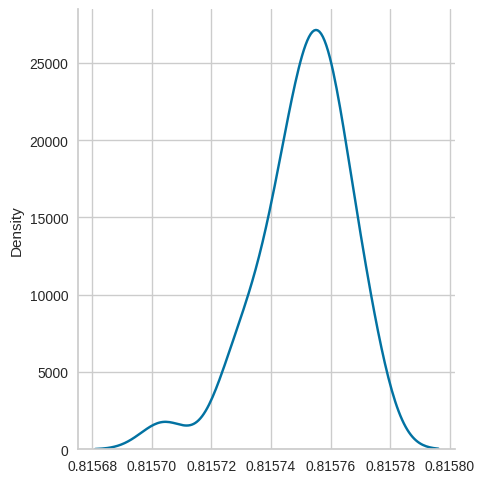

In [818]:
sns.displot(result_polynomial_30, kind = 'kde')

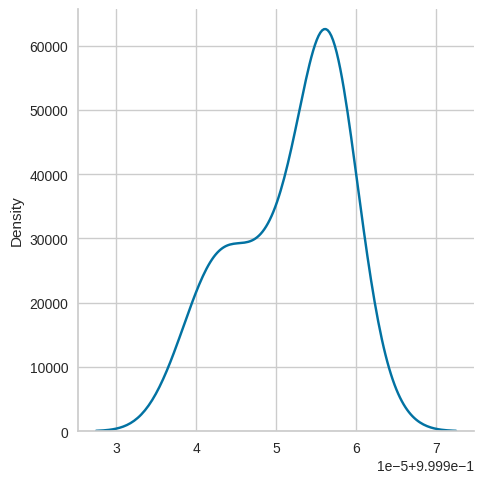

In [819]:
sns.displot(result_decision_tree_30, kind = 'kde')

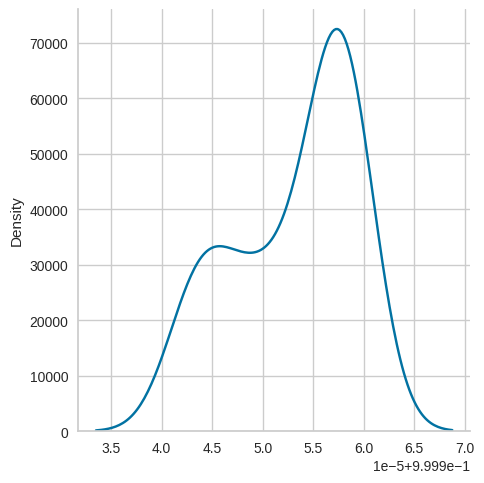

In [820]:
sns.displot(result_random_forest_30, kind = 'kde')

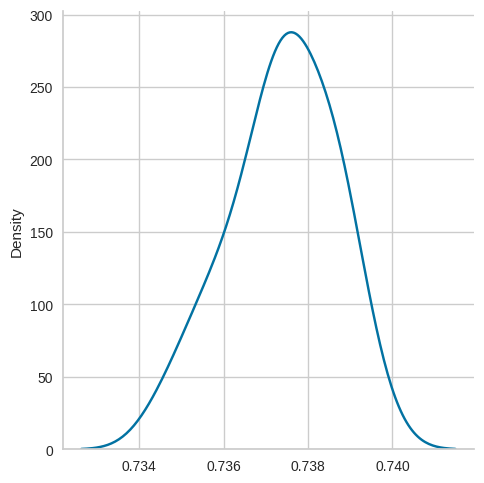

In [821]:
sns.displot(result_neural_network_30, kind = 'kde')

**Hypothesis Testing with ANOVA and Tukey (dados normalizados)**

In [822]:
# se p < alpha (0.05), os dados dos algoritmos são diferentes
_, p = f_oneway(result_polynomial_30, result_decision_tree_30, result_random_forest_30, result_neural_network_30)
p

np.float64(1.529539591641504e-263)

In [823]:
result_algorithm_30 = {'accuracy': np.concatenate([result_polynomial_30, result_decision_tree_30, result_random_forest_30, result_neural_network_30]),
              'algorithm': ['polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial',
               'decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree',
               'random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest',
               'neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network']}

In [824]:
results_test_30_df = pd.DataFrame(result_algorithm_30)
results_test_30_df

,accuracy,algorithm
0,0.815768,polynomial
1,0.815755,polynomial
2,0.815772,polynomial
3,0.815773,polynomial
4,0.815757,polynomial
...,...,...
115,0.735835,neural_network
116,0.739023,neural_network
117,0.737063,neural_network
118,0.737519,neural_network


In [825]:
compare_algorithm_30 = MultiComparison(results_test_30_df['accuracy'], results_test_30_df['algorithm'])

In [826]:
statistical_test_30 = compare_algorithm_30.tukeyhsd()
print(statistical_test_30)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1         group2     meandiff p-adj  lower   upper  reject
-------------------------------------------------------------------
 decision_tree neural_network  -0.2626   0.0  -0.263 -0.2621   True
 decision_tree     polynomial  -0.1842   0.0 -0.1846 -0.1838   True
 decision_tree  random_forest      0.0   1.0 -0.0004  0.0004  False
neural_network     polynomial   0.0784   0.0  0.0779  0.0788   True
neural_network  random_forest   0.2626   0.0  0.2621   0.263   True
    polynomial  random_forest   0.1842   0.0  0.1838  0.1846   True
-------------------------------------------------------------------


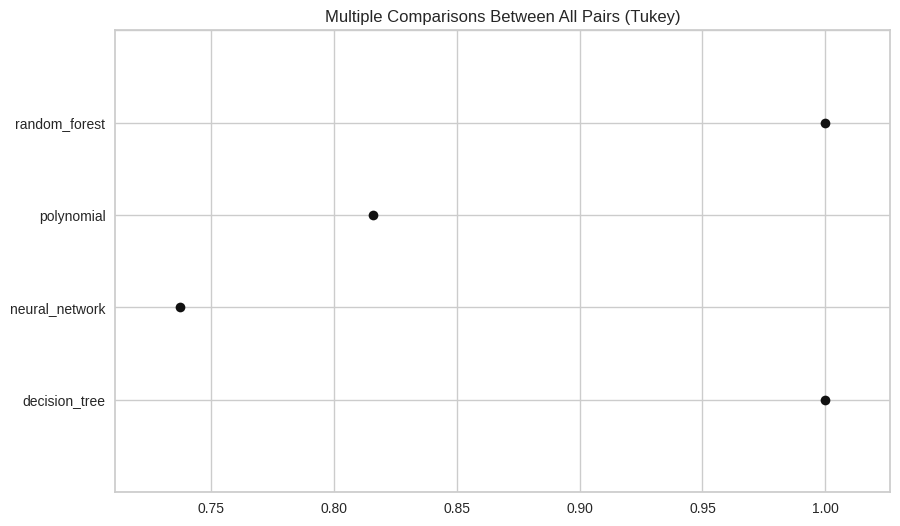

In [827]:
statistical_test_30.plot_simultaneous();

**Hypothesis Testing with Kruskal-Wallis and Nemenyi post-hoc test (dados não normalizados)**

In [828]:
# Conduct the Kruskal-Wallis Test
result_KW_test_30 = stats.kruskal(result_polynomial_30, result_decision_tree_30, result_random_forest_30, result_neural_network_30)
print (result_KW_test_30)

KruskalResult(statistic=np.float64(100.76584022038571), pvalue=np.float64(1.0637022593489887e-21))


/tmp/ipykernel_6569/1005416297.py:2: DeprecationWarning:

Please import `kruskal` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.



In [829]:
# Conduct the Nemenyi post-hoc test
# Combine three groups into one array
!pip install scipy scikit-posthocs numpy
import scikit_posthocs as sp

In [830]:
# Conduct the Nemenyi post-hoc test
# Combine three groups into one array
data_Nemenyi_30 = np.array([result_polynomial_30, result_decision_tree_30, result_random_forest_30,result_neural_network_30])
result_Nemenyi_test_30 = sp.posthoc_nemenyi_friedman(data_Nemenyi_30.T)
print (result_Nemenyi_test_30)

          0             1             2             3
0  1.000000  8.334217e-04  1.191036e-06  1.435777e-02
1  0.000833  1.000000e+00  4.992973e-01  6.276335e-11
2  0.000001  4.992973e-01  1.000000e+00  1.221245e-15
3  0.014358  6.276335e-11  1.221245e-15  1.000000e+00


# **Results Analysis (60)**
Resultados com 60 testes na validação cruzada

In [831]:
#result_decision_tree3 = [0.999943146521737, 0.9999567872776005, 0.9999570673775097, 0.9999447390226738, 0.9999376454084133, 0.999942963582248, 0.9999414348060996, 0.9999569930634793, 0.9999570138284503, 0.9999530645177945, 0.9999638593656359, 0.9999498129770293, 0.9999570823049837, 0.9999568919139575, 0.9999493336871919, 0.9999568136593554, 0.9999569723344848, 0.9999532392503324, 0.999944578356408, 0.9999606251231302, 0.9999501405949642, 0.9999532163257134, 0.9999571614194073, 0.9999416789478579, 0.999941612772157, 0.9999551958116679, 0.9999496247625833, 0.9999566901024277, 0.9999548086058194, 0.9999588800396724, 0.9999567432581535, 0.9999552588619194, 0.999957037945288, 0.9999494450804705, 0.9999400499555271, 0.9999571646851584, 0.9999588468938274, 0.9999569655109679, 0.999957125477113, 0.9999408476837008, 0.9999584746326745, 0.9999531786234825, 0.9999567945582211, 0.9999566716083967, 0.9999572062049455, 0.9999410163909385, 0.9999582597007525, 0.9999568991907546, 0.9999571078776477, 0.9999553372506954, 0.9999568211184998, 0.9999588130321382, 0.999955252354194, 0.9999570077318157, 0.9999568771419935, 0.9999671140709111, 0.9999581596348325, 0.9999546232302775, 0.9999569058645212, 0.9999567929864941, 0.9999557360528787, 0.9999571167234583, 0.9999569505745439, 0.9999429726750684, 0.999958512178788, 0.9999572984674165, 0.9999570642572214, 0.999961330368623, 0.9999571349449123, 0.9999554082280644, 0.9999378185094763, 0.9999500675232376, 0.9999569457381565, 0.9999413850429638, 0.9999552568565612, 0.9999570055446872, 0.9999580692991582, 0.9999583352336417, 0.9999552262146996, 0.9999444287736035, 0.9999478816580336, 0.9999569347527167, 0.9999448375876853, 0.9999599752743655, 0.9999571451325142, 0.999939788728778, 0.9999451890616221, 0.9999571273877024, 0.9999570628953682, 0.999958689591903, 0.999944562318014, 0.9999588894050524, 0.9999569979587098, 0.9999412360612411, 0.999956535869825, 0.9999569289461896, 0.999957095122906, 0.9999420241075754, 0.9999553588622783, 0.9999571040669263, 0.9999547519672074, 0.9999360328402946, 0.9999535847482168, 0.9999567156244981, 0.999957211009581, 0.9999710114397026, 0.9999574472225208, 0.9999569174841492, 0.9999569676132595, 0.9999671431959035, 0.9999553496264337, 0.9999569584436709, 0.9999555636774042, 0.9999583450505911, 0.9999570377716935, 0.9999498153105669, 0.9999519782955121, 0.9999463440773606, 0.9999571288973117, 0.9999569109199575]
result_polynomial_60 = [0.8165713273817718, 0.8165665923950855, 0.8165817936971588, 0.8165786898565286, 0.816621698737488, 0.8165949909316341, 0.816599894556442, 0.816598019822872, 0.816602543484182, 0.8166446683849491, 0.8166176632781763, 0.8165890657342212, 0.8166057532335378, 0.8166118436677071, 0.8165997034202824, 0.81656728445386, 0.8165976760938472, 0.8165475264359136, 0.8166122102911368, 0.8166073777434088, 0.8166013266071788, 0.8165843712539847, 0.816562679449961, 0.8165785093695323, 0.8165967921824315, 0.8166114974365621, 0.816586452159697, 0.8166035233999807, 0.8166026073129771, 0.8165848681297246, 0.8166424272148612, 0.816571220957955, 0.8165267038220391, 0.8165895018697687, 0.8166114881136898, 0.8165847895807646, 0.8165851114662081, 0.8165751782793704, 0.8166180373910211, 0.8166038985496293, 0.8166003489750105, 0.8166013902923235, 0.8166011611414986, 0.8165902253098784, 0.816574191602332, 0.8165911658013982, 0.8166317919515088, 0.8165914927505823, 0.8166096096375234, 0.8165631465081479, 0.8165706345224497, 0.8165770236057069, 0.8166157627122352, 0.816592125031153, 0.8165984921152962, 0.8165904746721517, 0.8165668473323394, 0.8165772932193586, 0.816602318328632, 0.8166388321069145]
#result_polynomial3 =[0.6265713273817718, 0.6265665923950855, 0.6265817936971588, 0.6265786898565286, 0.626621698737488, 0.6265949909316341, 0.626599894556442, 0.626598019822872, 0.626602543484182, 0.6266446683849491, 0.6266176632781763, 0.6265890657342212, 0.6266057532335378, 0.6266118436677071, 0.6265997034202824, 0.62656728445386, 0.6265976760938472, 0.6265475264359136, 0.6266122102911368, 0.6266073777434088, 0.6266013266071788, 0.6265843712539847, 0.626562679449961, 0.6265785093695323, 0.6265967921824315, 0.6266114974365621, 0.626586452159697, 0.6266035233999807, 0.6266026073129771, 0.6265848681297246, 0.6266424272148612, 0.626571220957955, 0.6265267038220391, 0.6265895018697687, 0.6266114881136898, 0.6265847895807646, 0.6265851114662081, 0.6265751782793704, 0.6266180373910211, 0.6266038985496293, 0.6266003489750105, 0.6266013902923235, 0.6266011611414986, 0.6265902253098784, 0.626574191602332, 0.6265911658013982, 0.6266317919515088, 0.6265914927505823, 0.6266096096375234, 0.6265631465081479, 0.6265706345224497, 0.6265770236057069, 0.6266157627122352, 0.626592125031153, 0.6265984921152962, 0.6265904746721517, 0.6265668473323394, 0.6265772932193586, 0.626602318328632, 0.6266388321069145]
result_decision_tree_60 = [0.9999484660048126, 0.9999575010454931, 0.9999567711554782, 0.9999459475921968, 0.9999431776258364, 0.9999454979281228, 0.9999441591309097, 0.9999566106554678, 0.9999589161196557, 0.9999554652614062, 0.9999593506338247, 0.9999533926484968, 0.9999571311661903, 0.9999531501045335, 0.9999444461071224, 0.9999566529019479, 0.9999570212646528, 0.9999505401933486, 0.9999463447276671, 0.9999569905651731, 0.9999528929961607, 0.9999529490836471, 0.9999589221141276, 0.9999440689644524, 0.999944403102964, 0.9999581540888871, 0.9999549734450014, 0.9999563793575847, 0.9999568835985782, 0.9999576338999013, 0.9999564554221614, 0.9999532592462484, 0.999959003338821, 0.9999530092639262, 0.9999457374645555, 0.9999555733191936, 0.9999538292457016, 0.9999550081865743, 0.9999581008680336, 0.9999429560760944, 0.9999544420985235, 0.9999526526028235, 0.9999581332573835, 0.9999566396116097, 0.9999576089187843, 0.9999464595025828, 0.9999561029636995, 0.9999537621963628, 0.9999586271902089, 0.9999590416701383, 0.9999584663013683, 0.999953855811748, 0.9999552017614324, 0.9999587282904144, 0.9999574815173121, 0.9999621830831478, 0.9999577112181928, 0.9999544842460513, 0.9999585364678463, 0.999955832232341]
result_random_forest_60 = [0.9999448391620099, 0.999958514264906, 0.9999570673775097, 0.9999447390226738, 0.9999359393511884, 0.9999446619893331, 0.9999414348060996, 0.9999553021122038, 0.9999570138284503, 0.9999530645177945, 0.999962184416941, 0.9999498129770293, 0.9999570823049837, 0.9999551777703968, 0.9999493336871919, 0.999955095841613, 0.9999552842285337, 0.9999532392503324, 0.999946270243085, 0.9999572388707858, 0.9999484429552385, 0.9999532163257134, 0.9999571614194073, 0.9999416789478579, 0.999941612772157, 0.9999551958116679, 0.9999513167071434, 0.9999583736603336, 0.9999581923852989, 0.999957198031462, 0.9999567432581535, 0.9999569619861182, 0.999957037945288, 0.9999494450804705, 0.9999400499555271, 0.999955457385545, 0.9999571417464814, 0.9999552711318426, 0.999957125477113, 0.9999391487599144, 0.9999567693330587, 0.9999531786234825, 0.9999567945582211, 0.9999583901983813, 0.9999572062049455, 0.9999410163909385, 0.9999582597007525, 0.9999568991907546, 0.9999571078776477, 0.9999553372506954, 0.9999568211184998, 0.9999588130321382, 0.9999569663845259, 0.9999570077318157, 0.9999568771419935, 0.999965424267075, 0.9999581596348325, 0.9999546232302775, 0.9999569058645212, 0.9999567929864941]
result_neural_network_60 = [0.7355617883876759, 0.7386313406242563, 0.7367214372779667, 0.7357803049451711, 0.7382879919537916, 0.7365781398463648, 0.7367255239155929, 0.7370336152303343, 0.7365604132389272, 0.735800300954838, 0.7360559201189976, 0.736265520906961, 0.7387531842423051, 0.736735217896185, 0.7388923555448701, 0.7377627489434608, 0.7376969551124896, 0.7373704212333626, 0.7357588697710584, 0.7375725395632089, 0.738004462501894, 0.736087304299287, 0.7352010377272595, 0.7387107806799057, 0.7379369373362578, 0.7381341363237767, 0.7370678465074582, 0.7345779906110821, 0.7359376051620564, 0.7368517509780408, 0.7356828685558556, 0.7372504075600227, 0.735954912903826, 0.7357766757010071, 0.7365270477706933, 0.7372907491940432, 0.7359776352421746, 0.7372713808969119, 0.7383911549839496, 0.7375136205254523, 0.7371898808660311, 0.7363794295379793, 0.7360060835367299, 0.7379240661872748, 0.7377362967853992, 0.737686684226016, 0.7368081228451133, 0.7373484431844067, 0.7340633263903394, 0.737081753332193, 0.7361777030162584, 0.7362476446227569, 0.735839653029098, 0.7374622778292671, 0.7366017172018027, 0.7378232419316892,  0.7390012362141941, 0.7392012362141941, 0.7394012362141941, 0.73960012362141941]

In [832]:
results_60_df = pd.DataFrame({'Polynomial': result_polynomial_60, 'Decision Tree': result_decision_tree_60, 'Random Forest': result_random_forest_60, "Neural Network": result_neural_network_60})
results_60_df

,Polynomial,Decision Tree,Random Forest,Neural Network
0,0.816571,0.999948,0.999945,0.735562
1,0.816567,0.999958,0.999959,0.738631
2,0.816582,0.999957,0.999957,0.736721
3,0.816579,0.999946,0.999945,0.735780
4,0.816622,0.999943,0.999936,0.738288
5,0.816595,0.999945,0.999945,0.736578
6,0.816600,0.999944,0.999941,0.736726
7,0.816598,0.999957,0.999955,0.737034
8,0.816603,0.999959,0.999957,0.736560
9,0.816645,0.999955,0.999953,0.735800


In [833]:
results_60_df.describe()

,Polynomial,Decision Tree,Random Forest,Neural Network
count,60.000000,60.000000,60.000000,60.000000
mean,0.816594,0.999954,0.999953,0.737038
std,0.000022,0.000005,0.000006,0.001188
min,0.816527,0.999943,0.999936,0.734063
25%,0.816579,0.999953,0.999951,0.736079
50%,0.816596,0.999956,0.999957,0.737051
75%,0.816604,0.999958,0.999957,0.737778
max,0.816645,0.999962,0.999965,0.739600


In [834]:
# Variance
results_60_df.var()

,0
Polynomial,4.763208e-10
Decision Tree,2.499887e-11
Random Forest,3.930091e-11
Neural Network,1.411314e-06


In [835]:
# Coefficient of variation (%)
(results_60_df.std() / results_60_df.mean()) * 100

,0
Polynomial,0.002673
Decision Tree,0.000500
Random Forest,0.000627
Neural Network,0.161184


# **Statistical Tests (60)**

**Test of normality of results**

In [836]:
alpha = 0.05
shapiro (result_polynomial_60), shapiro (result_decision_tree_60), shapiro (result_random_forest_60), shapiro (result_neural_network_60)

(ShapiroResult(statistic=np.float64(0.9800340099378327), pvalue=np.float64(0.4299762194813227)),
 ShapiroResult(statistic=np.float64(0.8589086684716053), pvalue=np.float64(5.636781894631199e-06)),
 ShapiroResult(statistic=np.float64(0.8305837364471894), pvalue=np.float64(8.526906746951769e-07)),
 ShapiroResult(statistic=np.float64(0.9867260211900024), pvalue=np.float64(0.7591215438801651)))

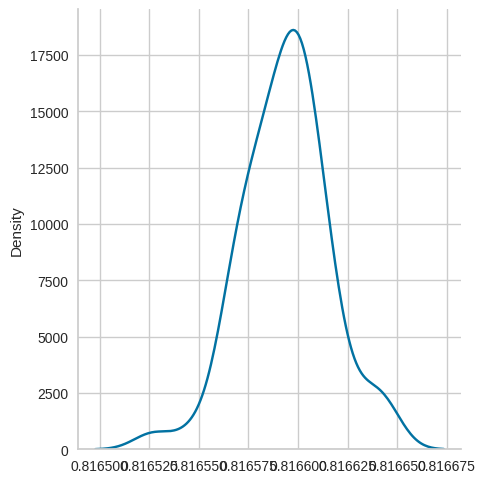

In [837]:
sns.displot(result_polynomial_60, kind = 'kde')

/tmp/ipykernel_6569/3798622946.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




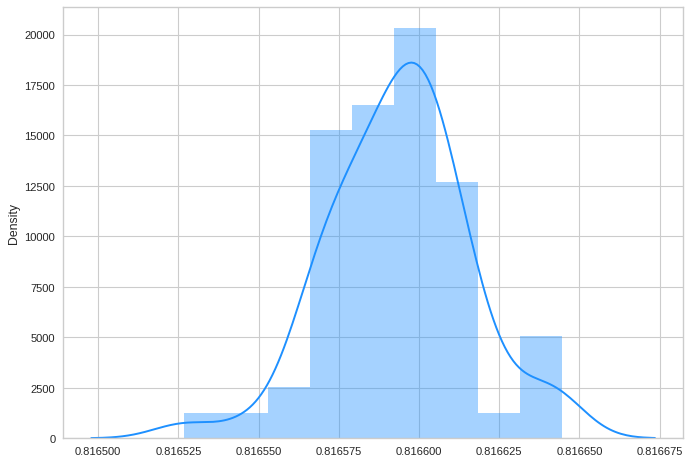

In [838]:
plt.figure(figsize=(10,7), dpi= 80)
sns.distplot(result_polynomial_60, color="dodgerblue", label="Compact",)
plt.show()

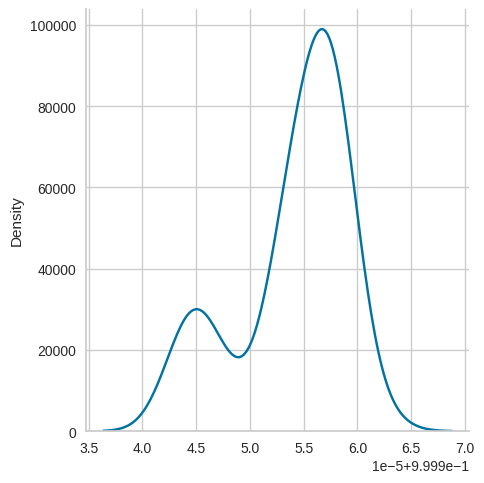

In [839]:
sns.displot(result_decision_tree_60, kind = 'kde')

/tmp/ipykernel_6569/867712040.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




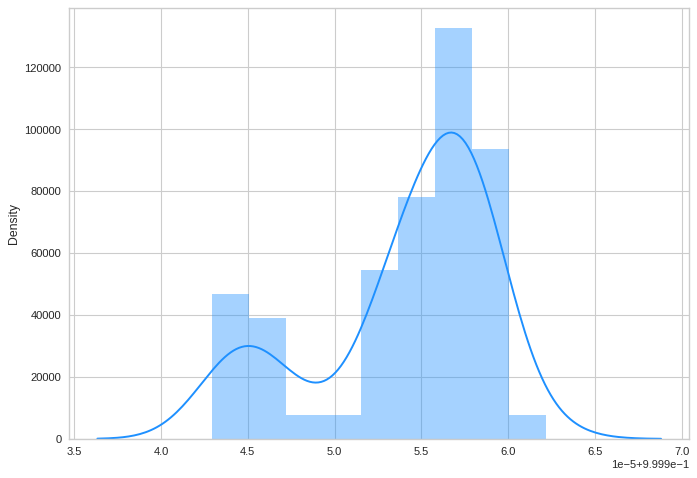

In [840]:
plt.figure(figsize=(10,7), dpi= 80)
sns.distplot(result_decision_tree_60, color="dodgerblue", label="Compact",)
plt.show()

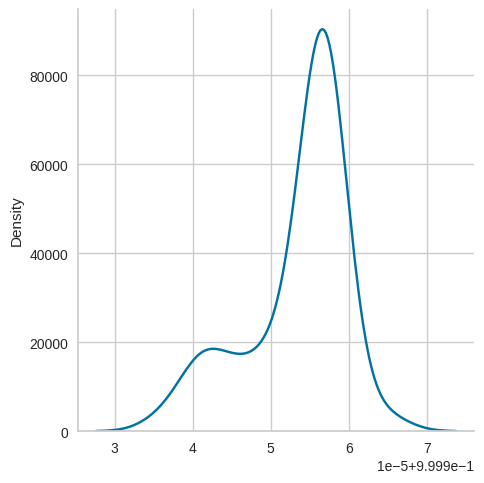

In [841]:
sns.displot(result_random_forest_60, kind = 'kde')

/tmp/ipykernel_6569/23757131.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




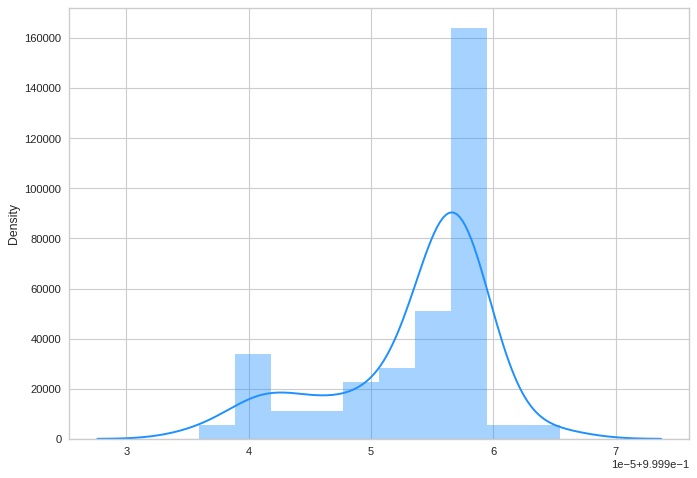

In [842]:
plt.figure(figsize=(10,7), dpi= 80)
sns.distplot(result_random_forest_60, color="dodgerblue", label="Compact",)
plt.show()

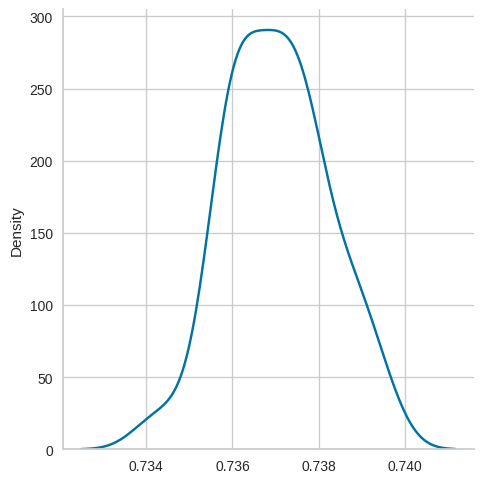

In [843]:
sns.displot(result_neural_network_60, kind = 'kde')

/tmp/ipykernel_6569/2952555192.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




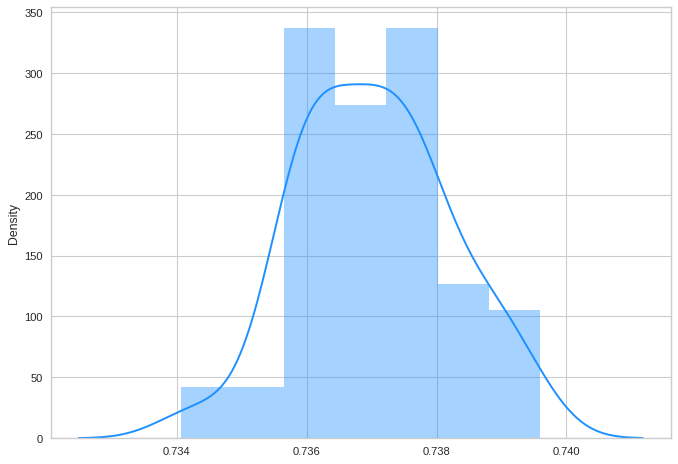

In [844]:
plt.figure(figsize=(10,7), dpi= 80)
sns.distplot(result_neural_network_60, color="dodgerblue", label="Compact",)
plt.show()

**Hypothesis Testing with ANOVA and Tukey (dados normalizados)**

In [845]:
# se p < alpha (0.05), há diferença estatística entre os algoritmos
_, p = f_oneway(result_polynomial_60, result_decision_tree_60,
                result_random_forest_60, result_neural_network_60)
print(p)

0.0


In [846]:
result_algorithm_60 = {'accuracy': np.concatenate([result_polynomial_60, result_decision_tree_60, result_random_forest_60, result_neural_network_60]),
              'algorithm': ['polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial',
               'decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree', 'decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree',
               'random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest',
               'neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network', 'neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network']}

In [847]:
results_test_60_df = pd.DataFrame(result_algorithm_60)
results_test_60_df

,accuracy,algorithm
0,0.816571,polynomial
1,0.816567,polynomial
2,0.816582,polynomial
3,0.816579,polynomial
4,0.816622,polynomial
...,...,...
235,0.737823,neural_network
236,0.739001,neural_network
237,0.739201,neural_network
238,0.739401,neural_network


In [848]:
compare_algorithm_60 = MultiComparison(results_test_60_df['accuracy'], results_test_60_df['algorithm'])

In [849]:
statistical_test_60 = compare_algorithm_60.tukeyhsd()
print(statistical_test_60)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1         group2     meandiff p-adj  lower   upper  reject
-------------------------------------------------------------------
 decision_tree neural_network  -0.2629   0.0 -0.2632 -0.2626   True
 decision_tree     polynomial  -0.1834   0.0 -0.1836 -0.1831   True
 decision_tree  random_forest     -0.0   1.0 -0.0003  0.0003  False
neural_network     polynomial   0.0796   0.0  0.0793  0.0798   True
neural_network  random_forest   0.2629   0.0  0.2626  0.2632   True
    polynomial  random_forest   0.1834   0.0  0.1831  0.1836   True
-------------------------------------------------------------------


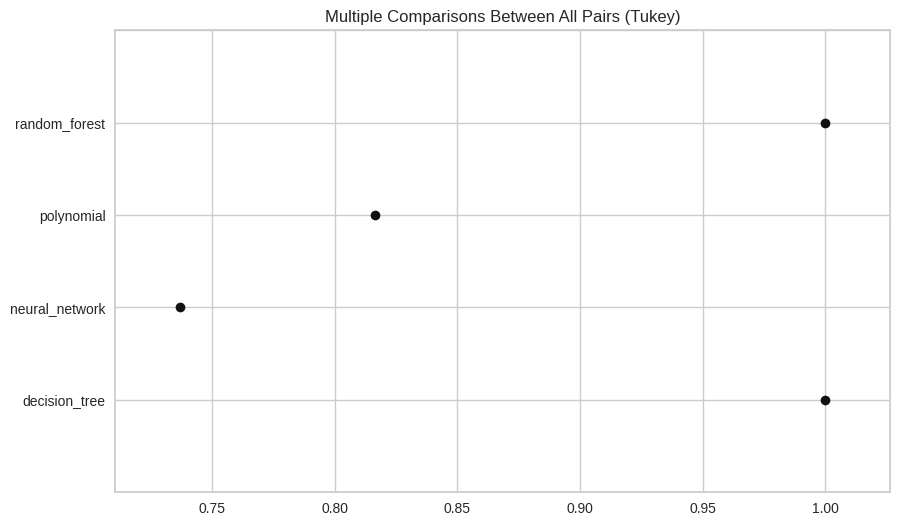

In [850]:
statistical_test_60.plot_simultaneous();

**Hypothesis Testing with Kruskal-Wallis and Nemenyi post-hoc test (dados não normalizados)**

In [851]:
# Conduct the Kruskal-Wallis Test
result_KW_test_60 = stats.kruskal(result_polynomial_60, result_decision_tree_60,
                                  result_random_forest_60, result_neural_network_60)
print (result_KW_test_60)

KruskalResult(statistic=np.float64(201.67313969571228), pvalue=np.float64(1.8349992749716806e-43))


/tmp/ipykernel_6569/2666321250.py:2: DeprecationWarning:

Please import `kruskal` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.



In [852]:
# Conduct the Nemenyi post-hoc test
# Combine three groups into one array
!pip install scipy scikit-posthocs numpy
import scikit_posthocs as sp

In [853]:
# Conduct the Nemenyi post-hoc test
data_Nemenyi_60 = np.array([result_polynomial_60, result_decision_tree_60,
                            result_random_forest_60, result_neural_network_60])
result_Nemenyi_test_60 = sp.posthoc_nemenyi_friedman(data_Nemenyi_60.T)
print (result_Nemenyi_test_60)

              0             1             2        3
0  1.000000e+00  1.108930e-10  1.109491e-08  0.00013
1  1.108930e-10  1.000000e+00  8.943255e-01  0.00000
2  1.109491e-08  8.943255e-01  1.000000e+00  0.00000
3  1.298172e-04  0.000000e+00  0.000000e+00  1.00000
